In [23]:
import warnings;
warnings.simplefilter('ignore')
from dcr import *

In [24]:
%matplotlib inline
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (16,9)
plt.rcParams.update({'font.size': 16})

In [3]:
def I(pi):
    return -math.log(pi, 2)

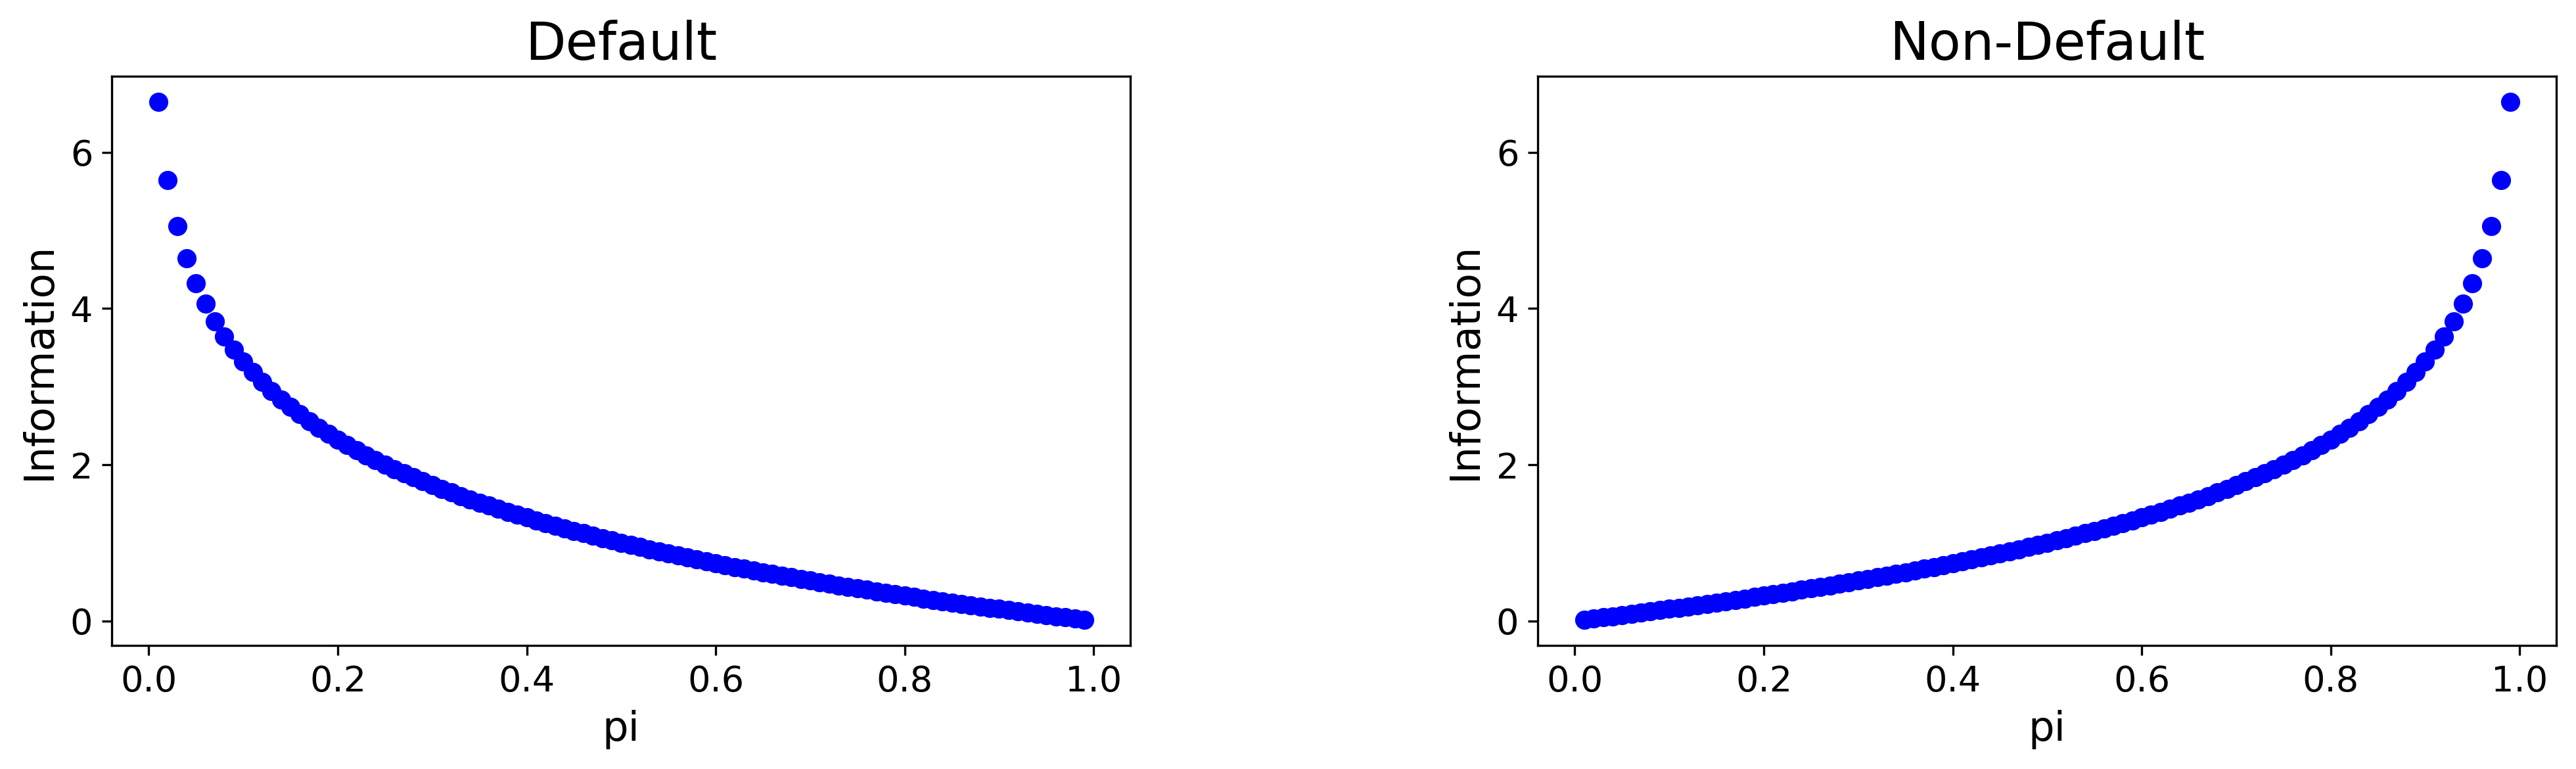

In [4]:
plt.subplots_adjust(hspace=0.4, wspace=0.4)

plt.subplot(221)
plt.title('Default')
for i in range(1, 100, 1):
    pi = i/100
    plt.xlabel('pi', fontsize=15)
    plt.ylabel('Information', fontsize=15)
    plt.tick_params(axis='both', labelsize=13)
    plt.plot(pi, I(pi), color='blue', marker='o')

plt.subplot(222)
plt.title('Non-Default')
for i in range(1, 100, 1):
    pi = i/100
    plt.xlabel('pi', fontsize=15)
    plt.ylabel('Information', fontsize=15)
    plt.tick_params(axis='both', labelsize=13)
    plt.plot(pi, I(1-pi), color='blue', marker='o')

plt.show()

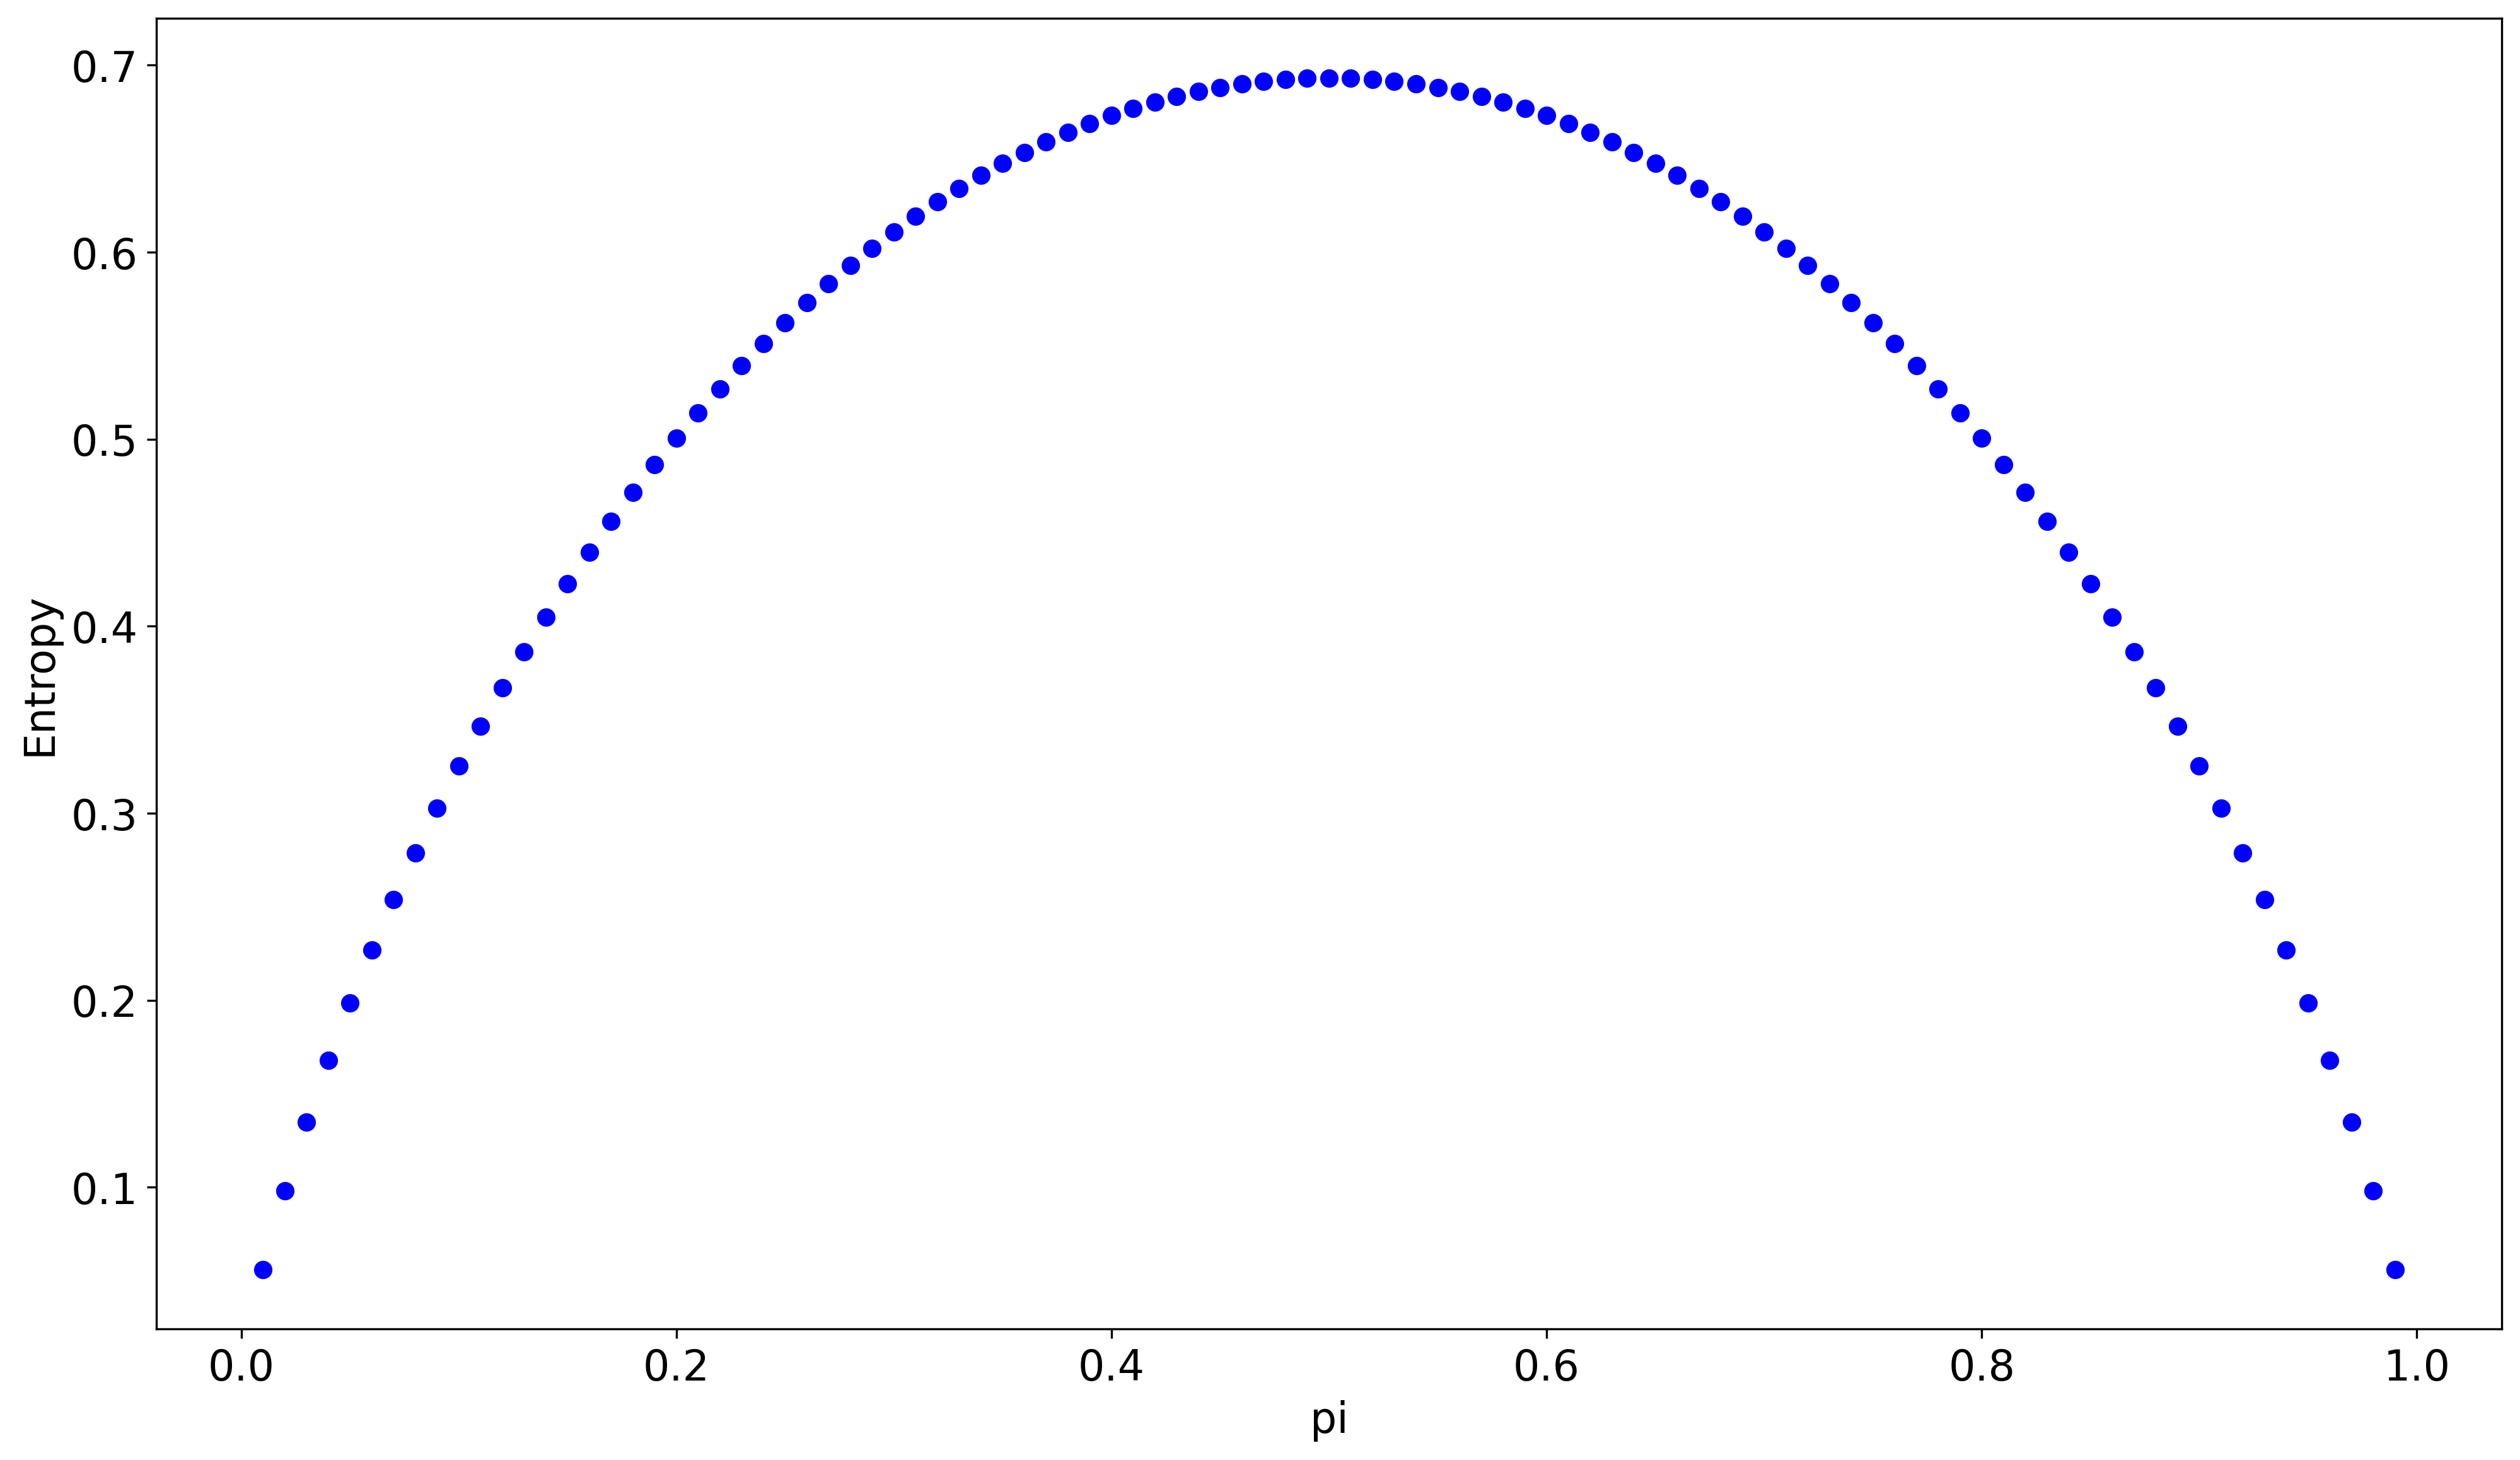

In [5]:
def Entropy(pi):
    return - pi * math.log(pi) - (1-pi) * math.log(1-pi)

for i in range(1, 100, 1):
    pi = i/100
    plt.xlabel('pi')
    plt.ylabel('Entropy')
    plt.plot(pi, Entropy(pi), color='blue', marker='o')
    

In [6]:
def CrossEntropy(pi, d):
    if d == 1:
        return -math.log(pi)
    else:
        return -math.log(1 - pi)

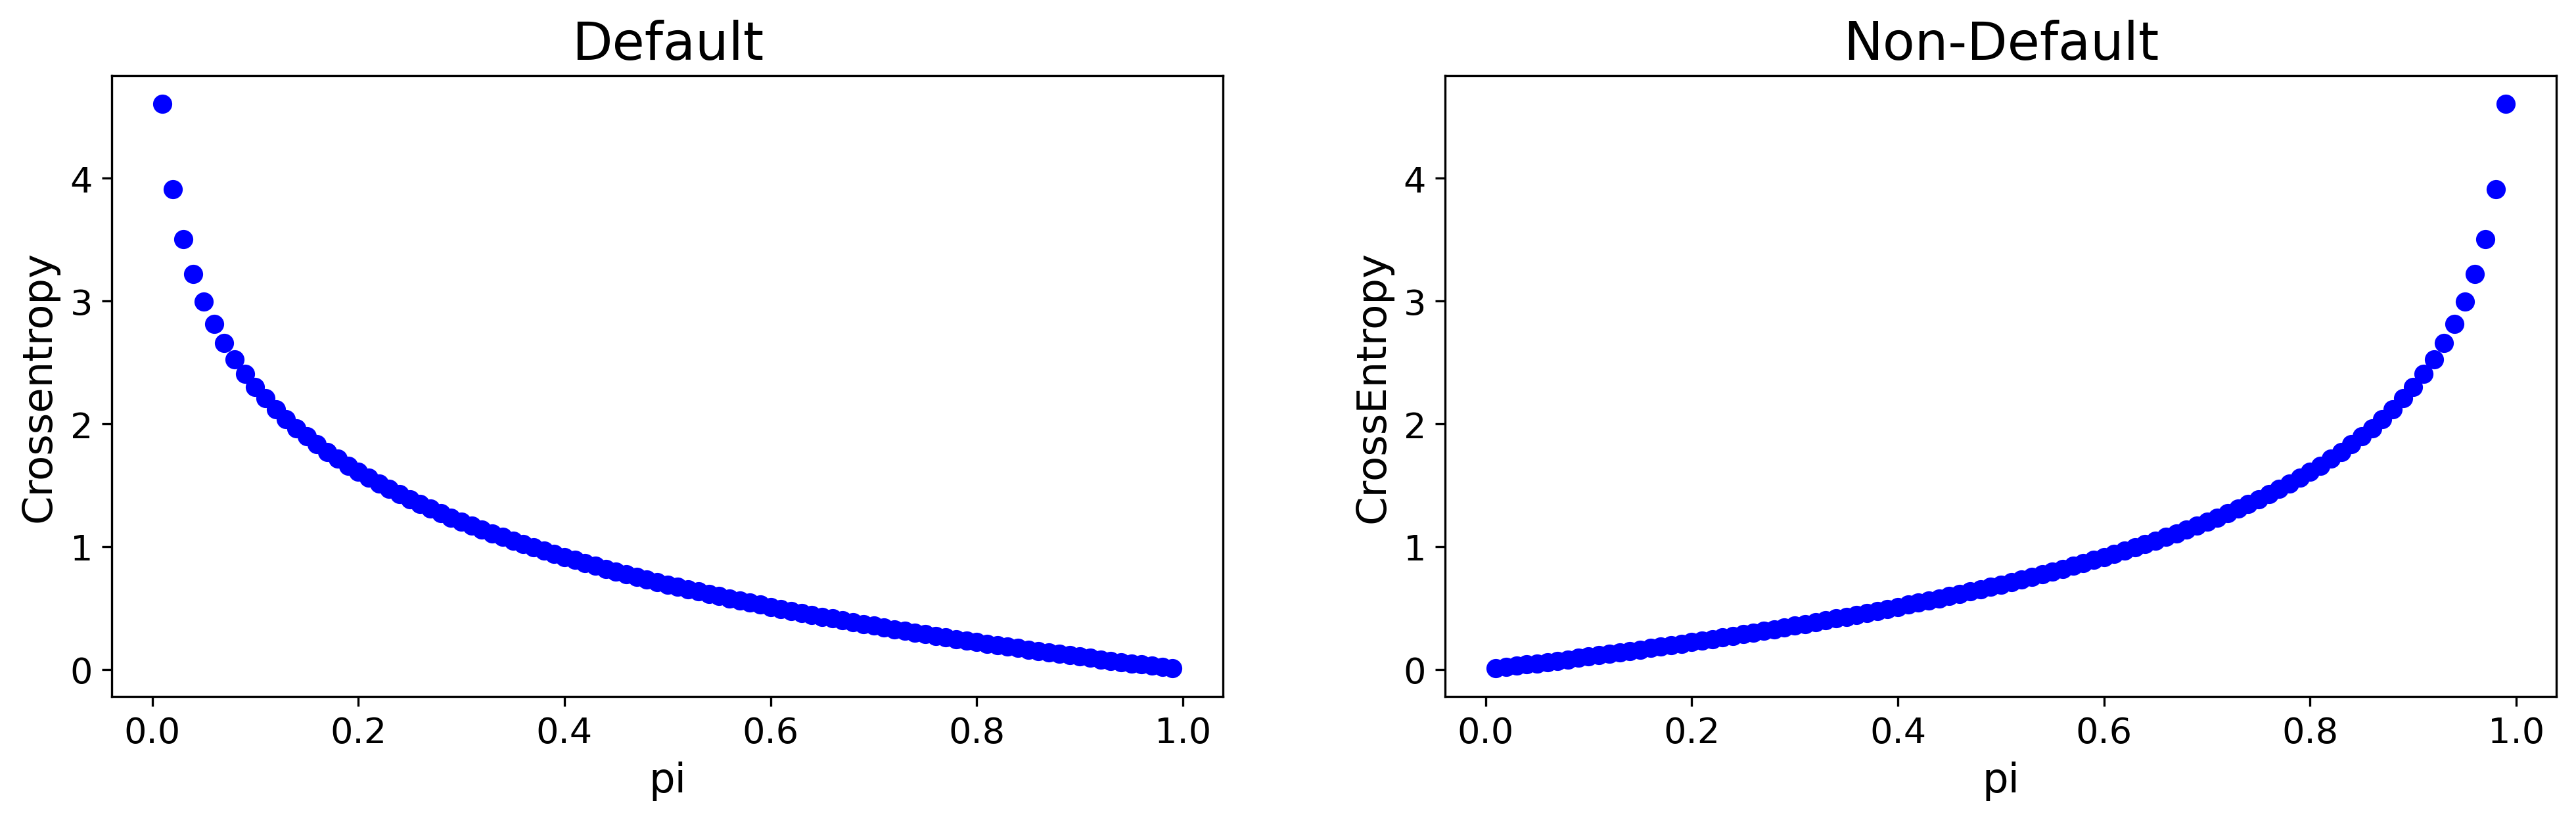

In [7]:
plt.subplot(221)
plt.title('Default')
for i in range(1, 100, 1):
    d = 1
    pi = i/100
    plt.xlabel('pi', fontsize=15)
    plt.ylabel('Crossentropy', fontsize=15)
    plt.tick_params(axis='both', labelsize=13)
    plt.plot(pi, CrossEntropy(pi, d), color='blue', marker='o')

plt.subplot(222)
plt.title('Non-Default')
for i in range(1, 100, 1):
    d = 0 
    pi = i/100
    plt.xlabel('pi', fontsize=15)
    plt.ylabel('CrossEntropy', fontsize=15)
    plt.tick_params(axis='both', labelsize=13)
    plt.plot(pi, CrossEntropy(pi, d), color='blue', marker='o')

plt.show()

z: -1.6829673572159562e-10
function: 2.949166103138755e-20
derivative: -3.4346272596244006e-10


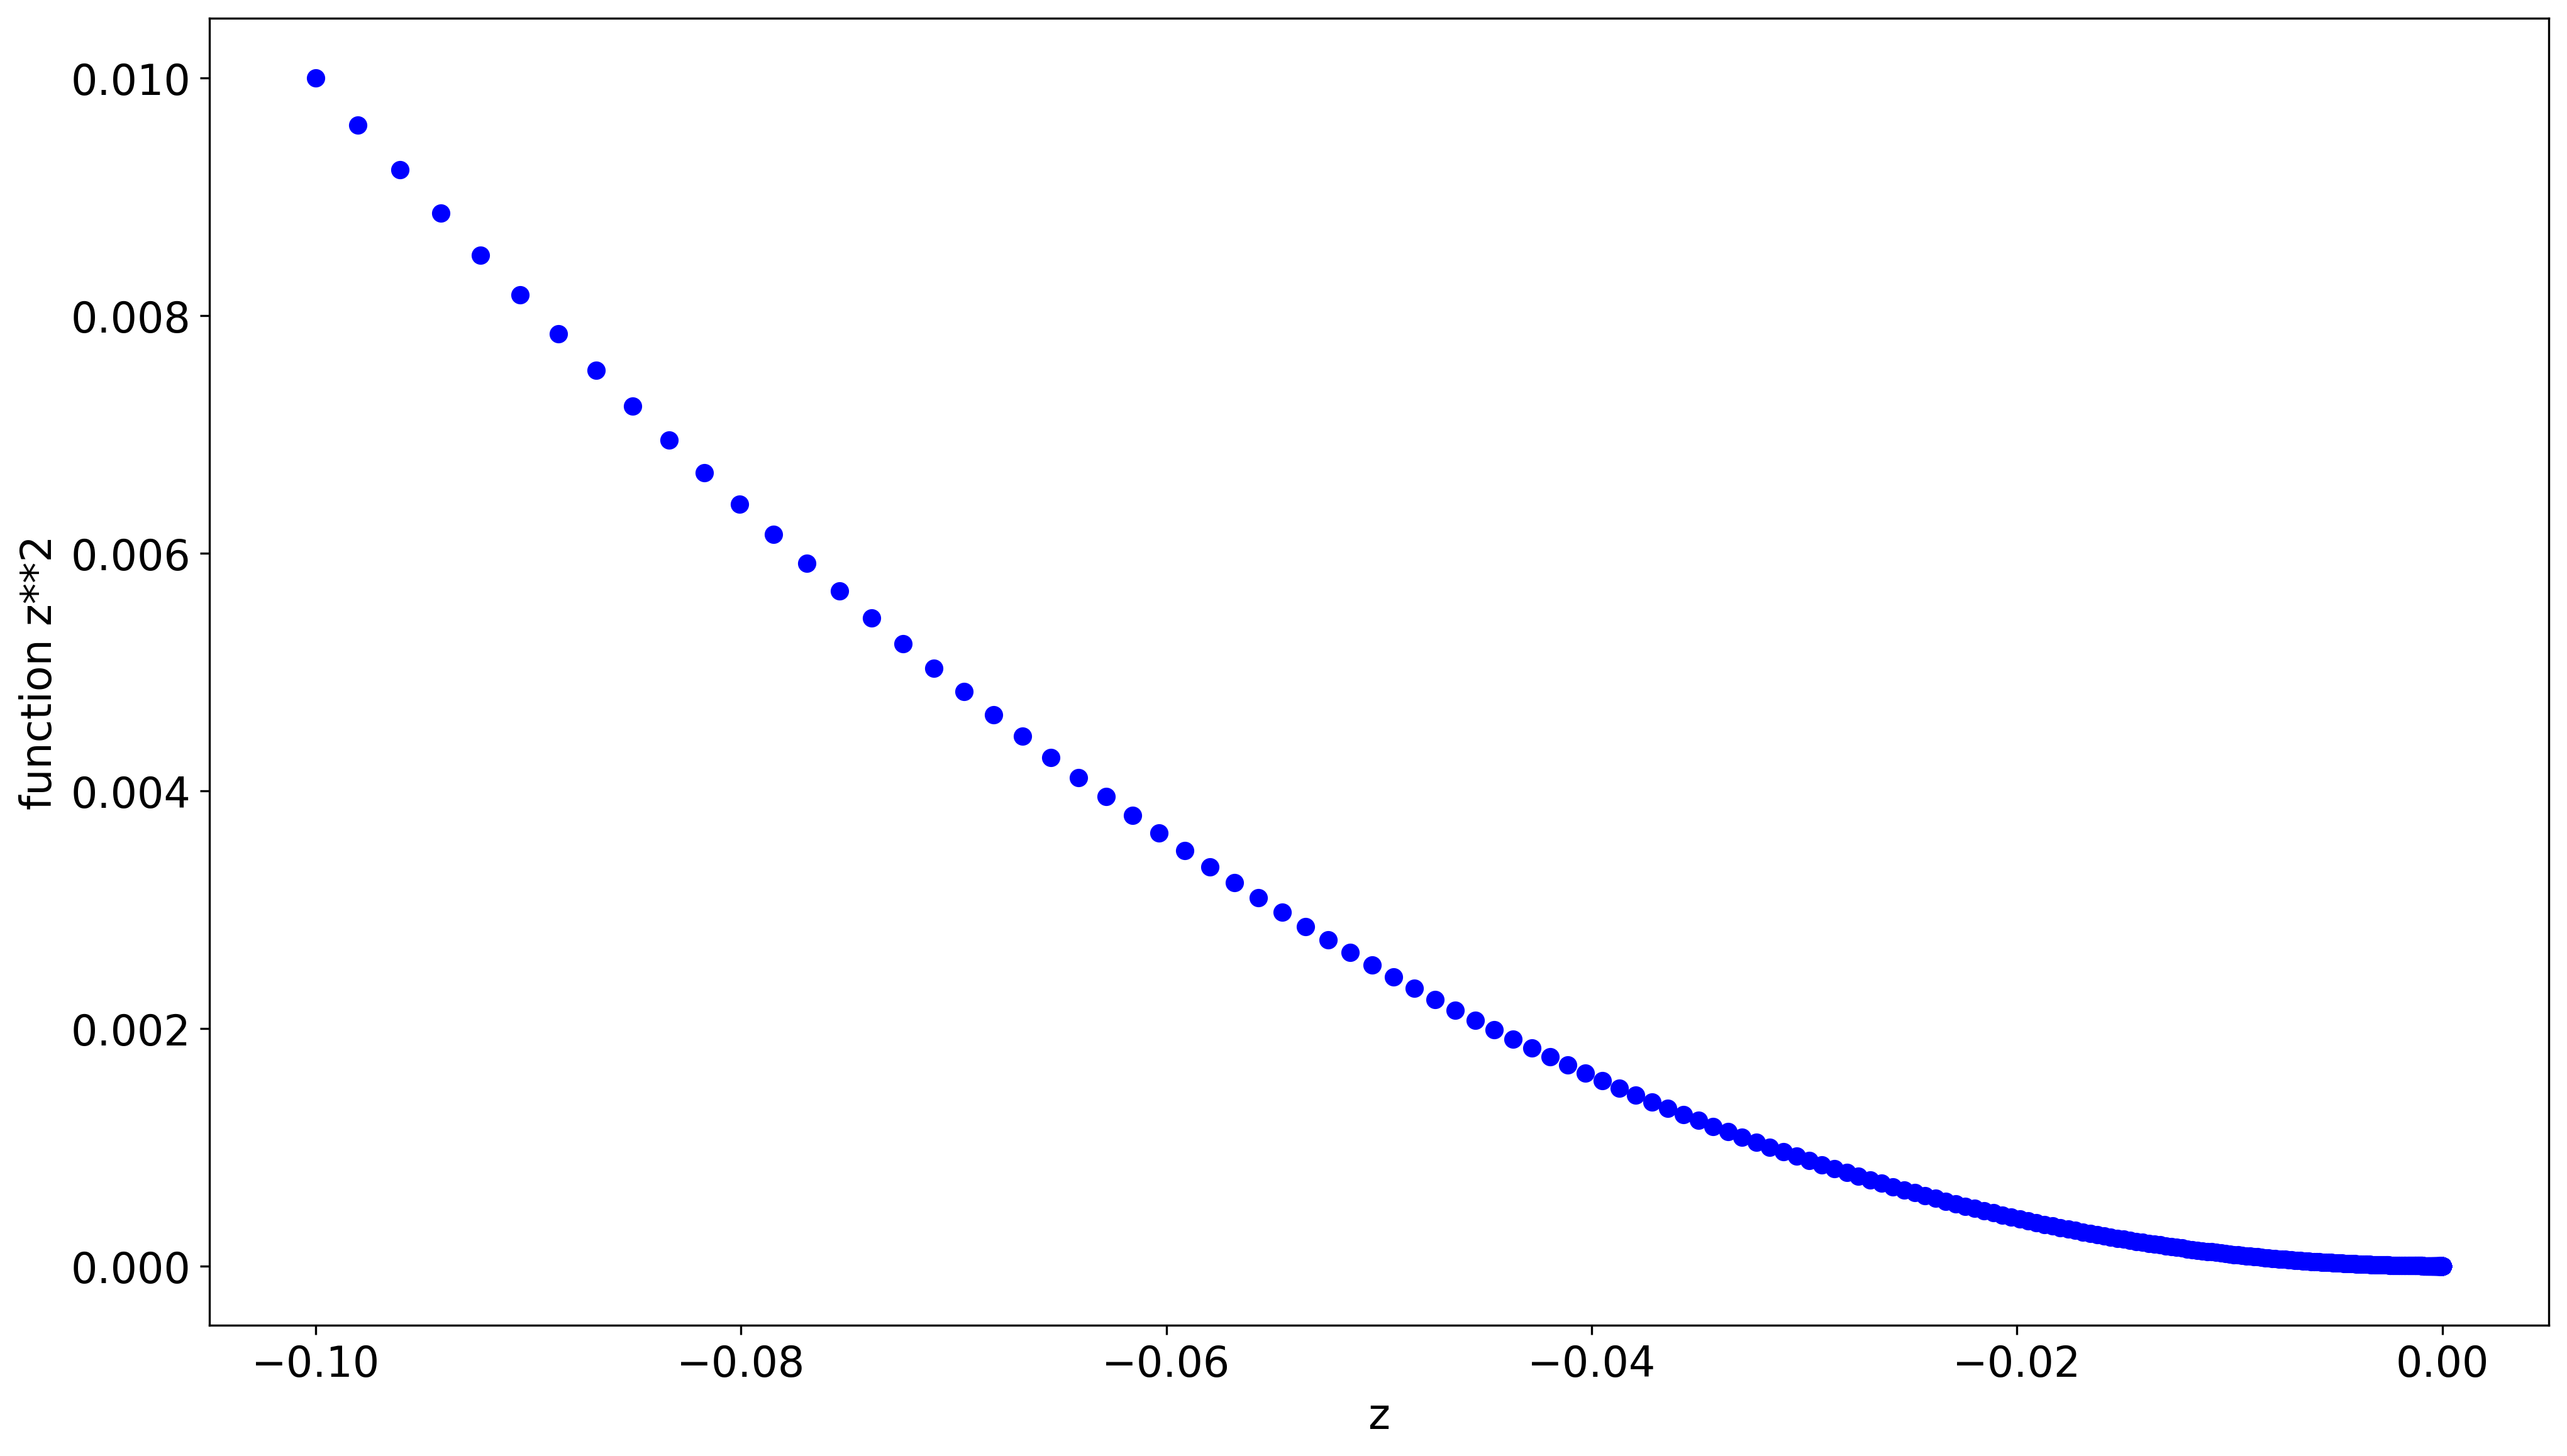

In [8]:
def fun(z):
    return z**2

def deriv_fun(z):
    return 2 * z

lr = 0.01
z_s = -0.1
for i in range(0,1000):
    d_f = deriv_fun(z_s)
    f = fun(z_s)
    plt.xlabel('z')
    plt.ylabel('function z**2')
    plt.plot(z_s, f, color='blue', marker='o')
    z_s = z_s - lr * d_f

print('z:', z_s)
print('function:', f)
print('derivative:', d_f)

In [11]:
x = np.array([0.35, 0.80, 0.55, 1.10])
y = np.array([0.3, 0.55, 0.5, 0.85])

Text(0, 0.5, 'LGD')

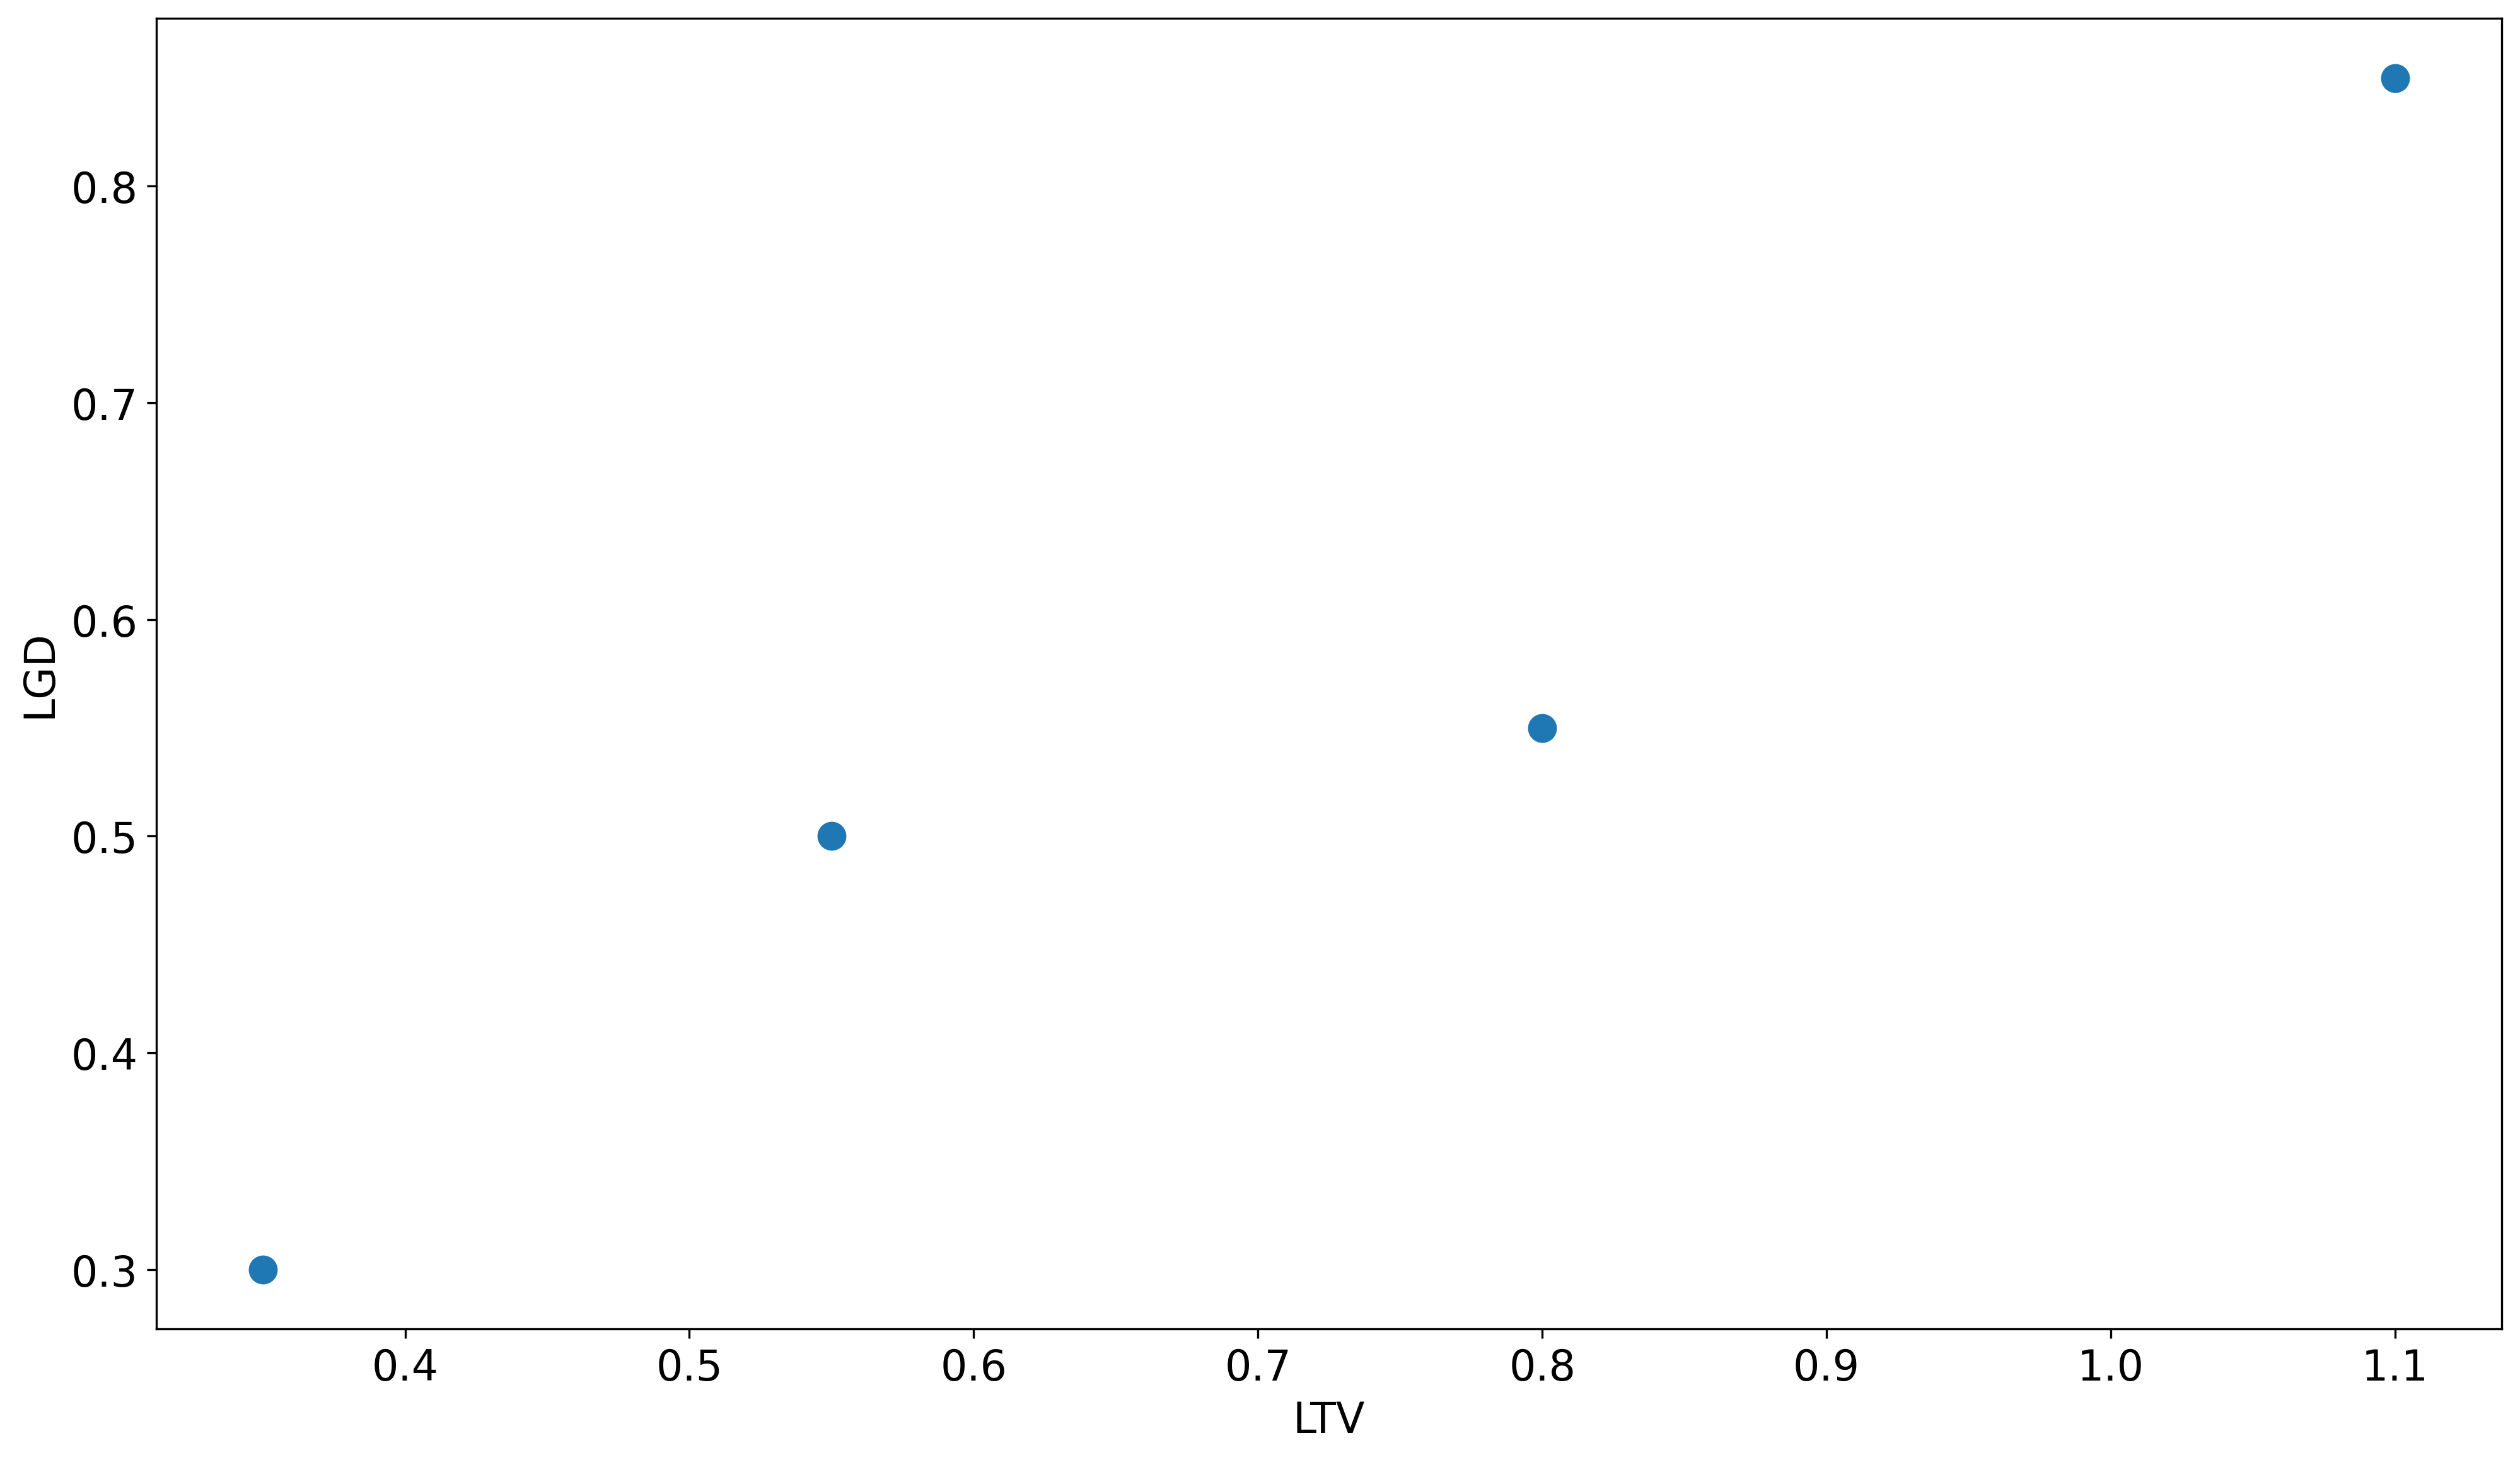

In [12]:
plt.scatter(x, y, marker='o', s=100)
plt.xlabel('LTV')
plt.ylabel('LGD')

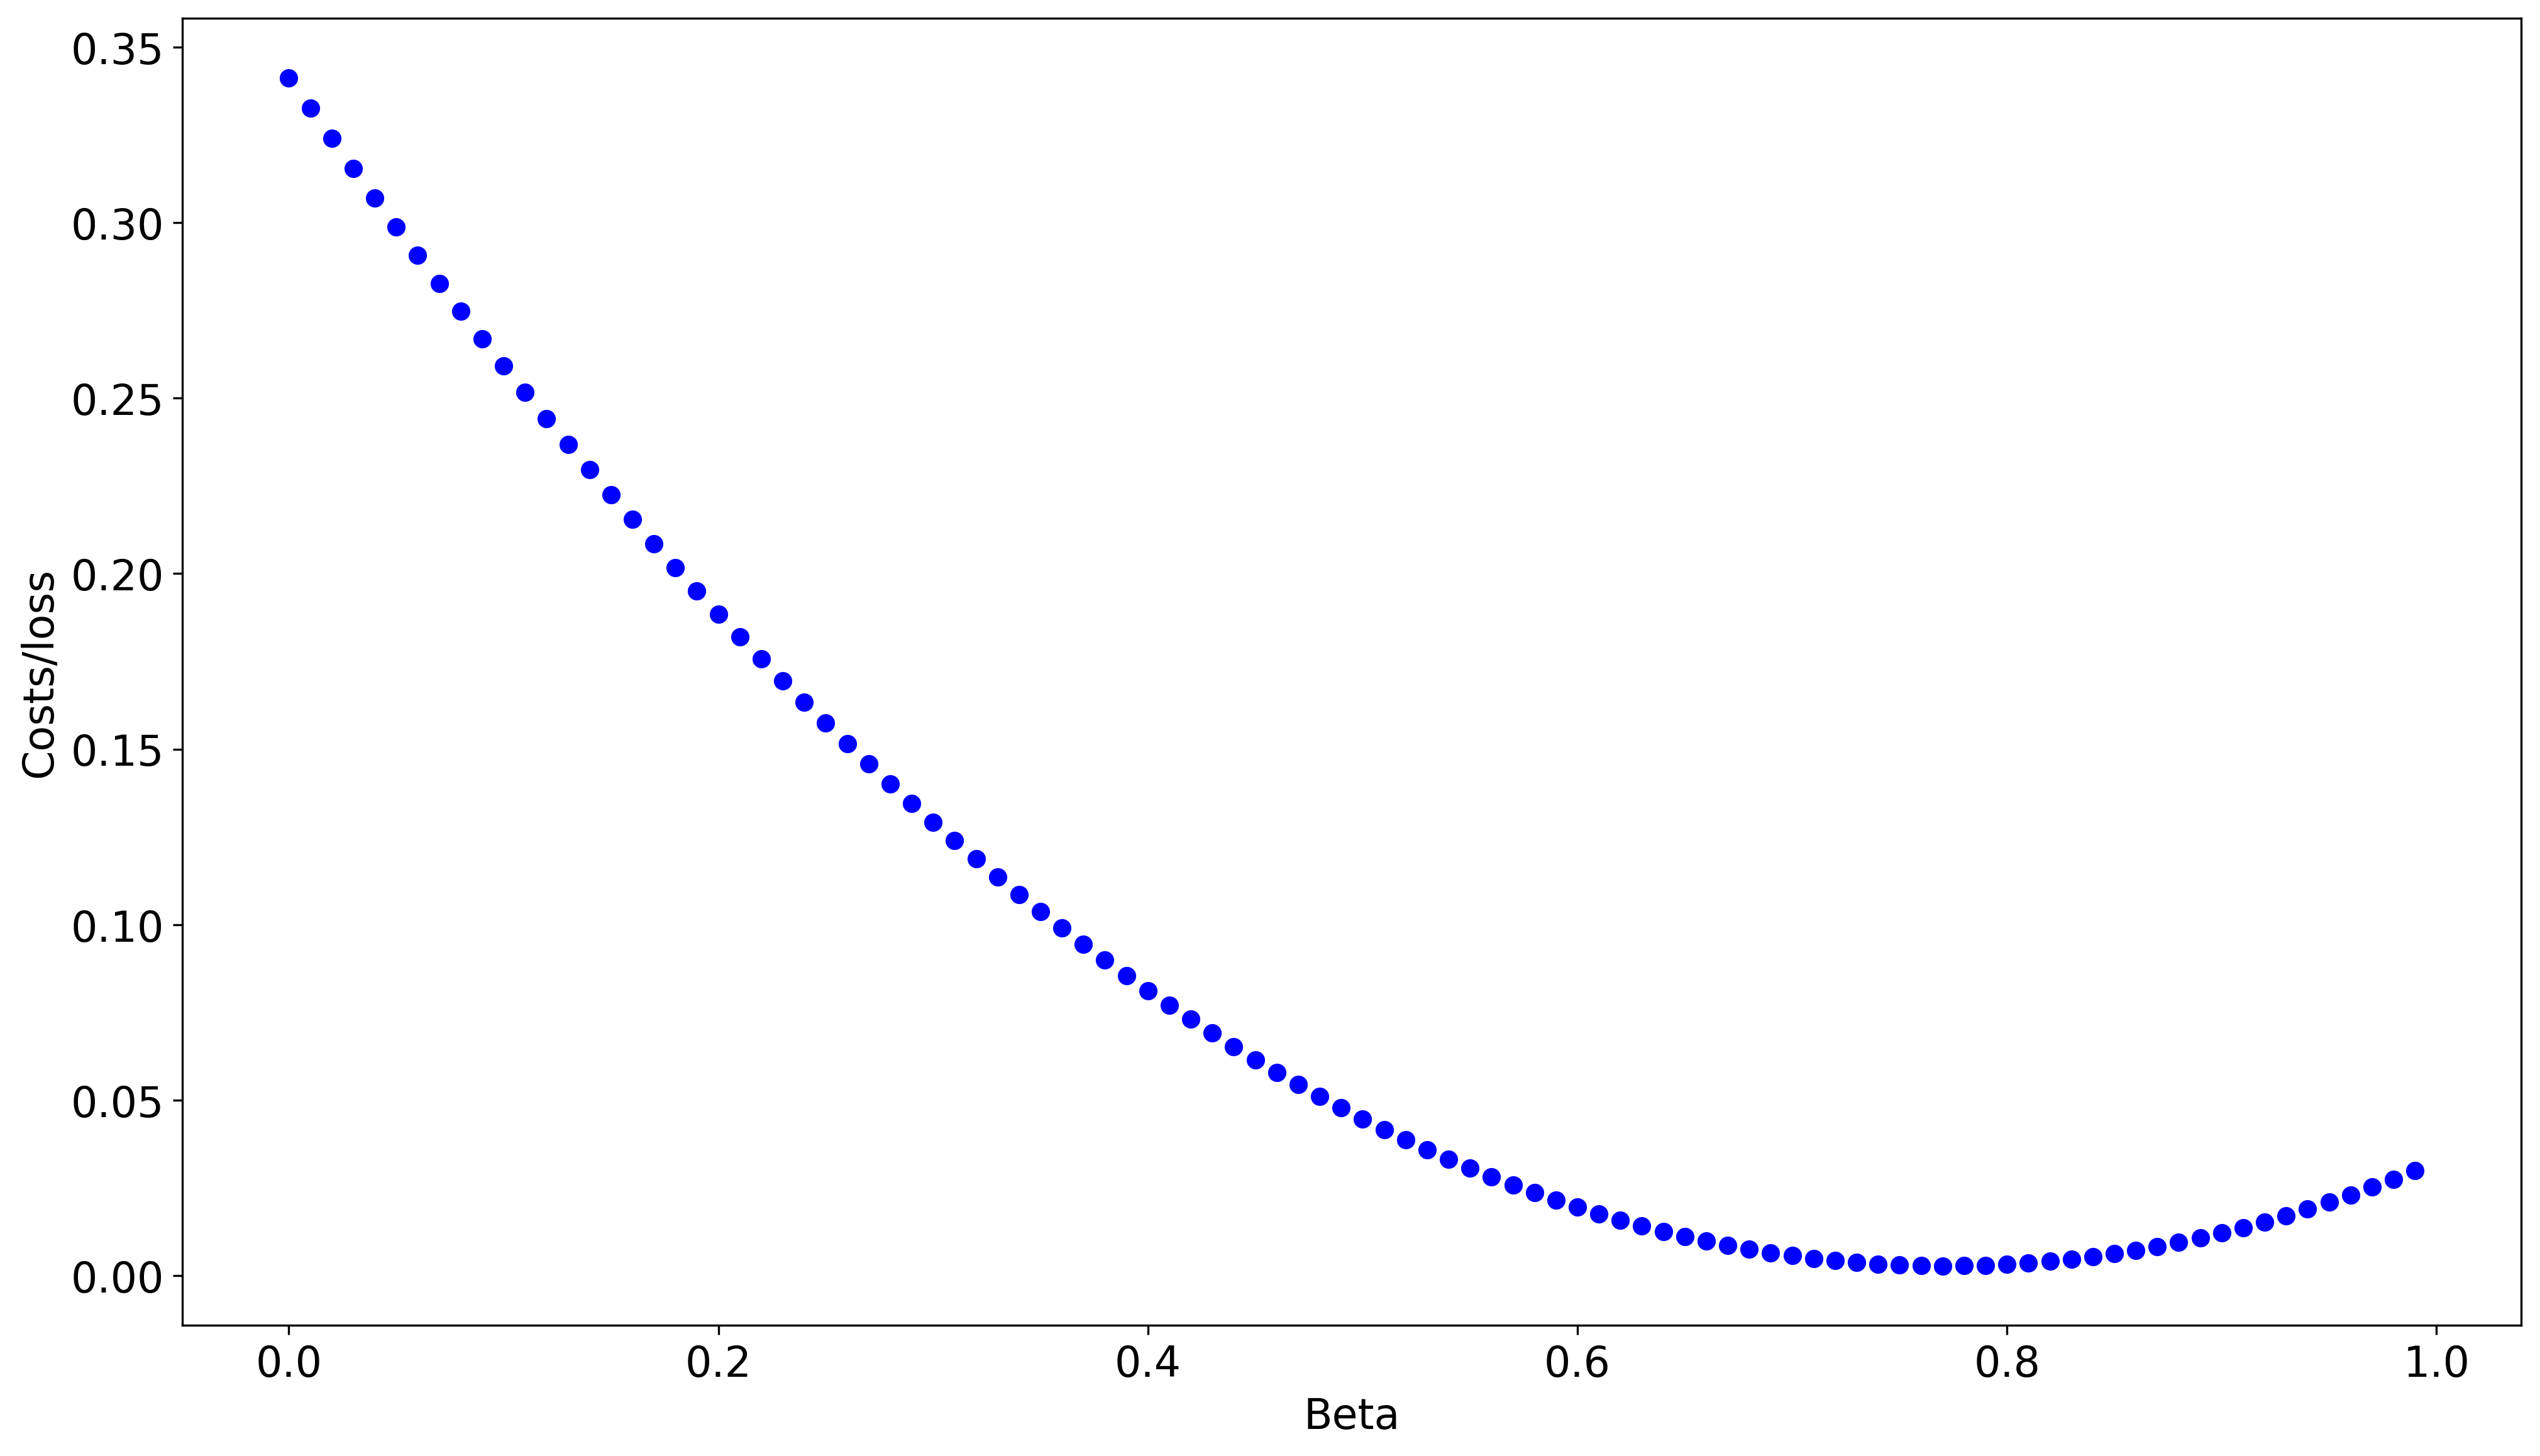

In [13]:
def J_cost_fun(beta):  
    y_pred = beta * x  
    costs = (y-y_pred)**2  
    cost = np.mean(costs)  
    return cost

for beta_s in range(0, 100, 1):  
    cost_beta = J_cost_fun(beta_s/100)  
    plt.xlabel('Beta')  
    plt.ylabel('Costs/loss')  
    plt.plot(beta_s/100, cost_beta, color='blue', marker='o') 


Solution for beta: 0.77


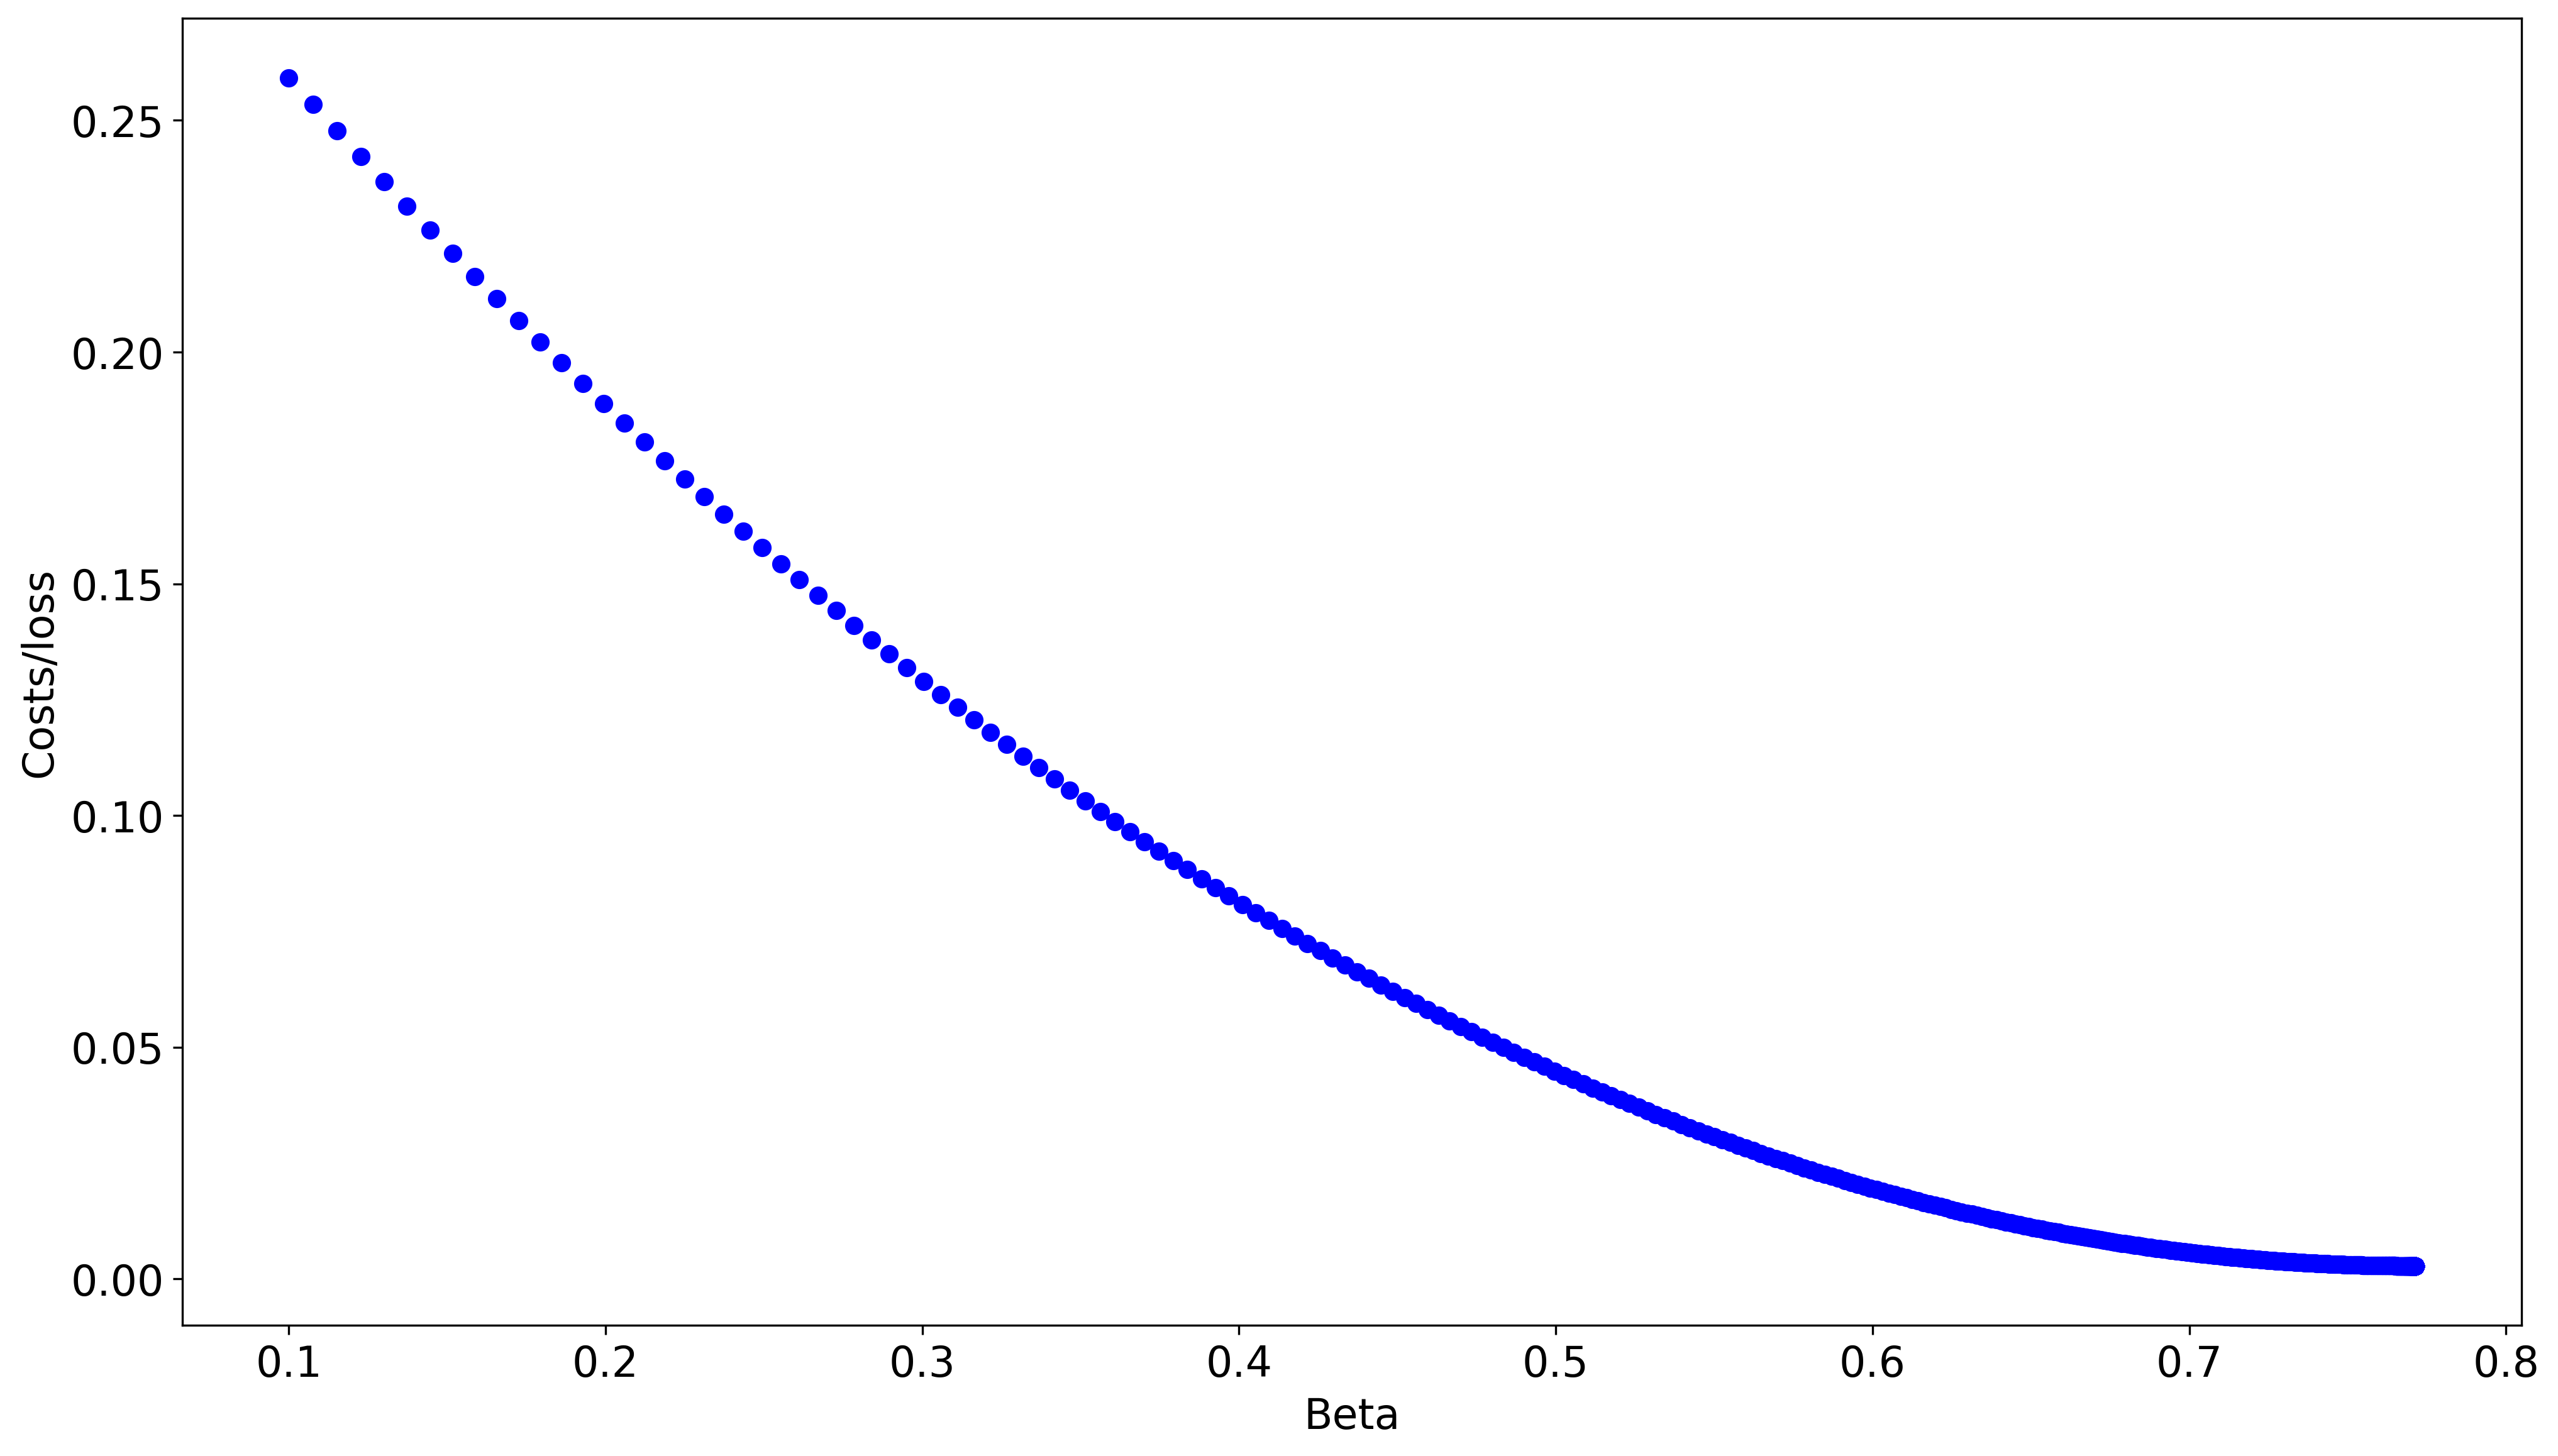

In [14]:
def J_deriv(beta):  
    y_pred = beta * x  
    tmp = np.mean(-2 * x * (y - y_pred))  
    return tmp  

lr = 0.01  
beta_s = 0.1  

for i in range(0,1000):  
    d_beta = J_deriv(beta_s)  
    cost = J_cost_fun(beta_s)  
    plt.xlabel('Beta')  
    plt.ylabel('Costs/loss')  
    plt.plot(beta_s, cost,color='blue', marker='o')
    beta_s = beta_s - lr * d_beta  
    
print('Solution for beta:', np.round(beta_s,2)) 

In [15]:
model = sm.OLS(y,x)  
results = model.fit()  
print('Solution for beta:', np.round(results.params,2))

Solution for beta: [0.77]


In [3]:
x = np.array([400, 300, 200, 100])
d = np.array([0, 0, 1, 1])

In [4]:
def J_cost_fun_bin(beta):
    pd_pred = np.exp(beta * x) / (1 + np.exp(beta * x))
    costs = d * np.log(pd_pred) + (1-d) * (np.log(1-pd_pred))
    cost = -np.mean(costs)
    return cost

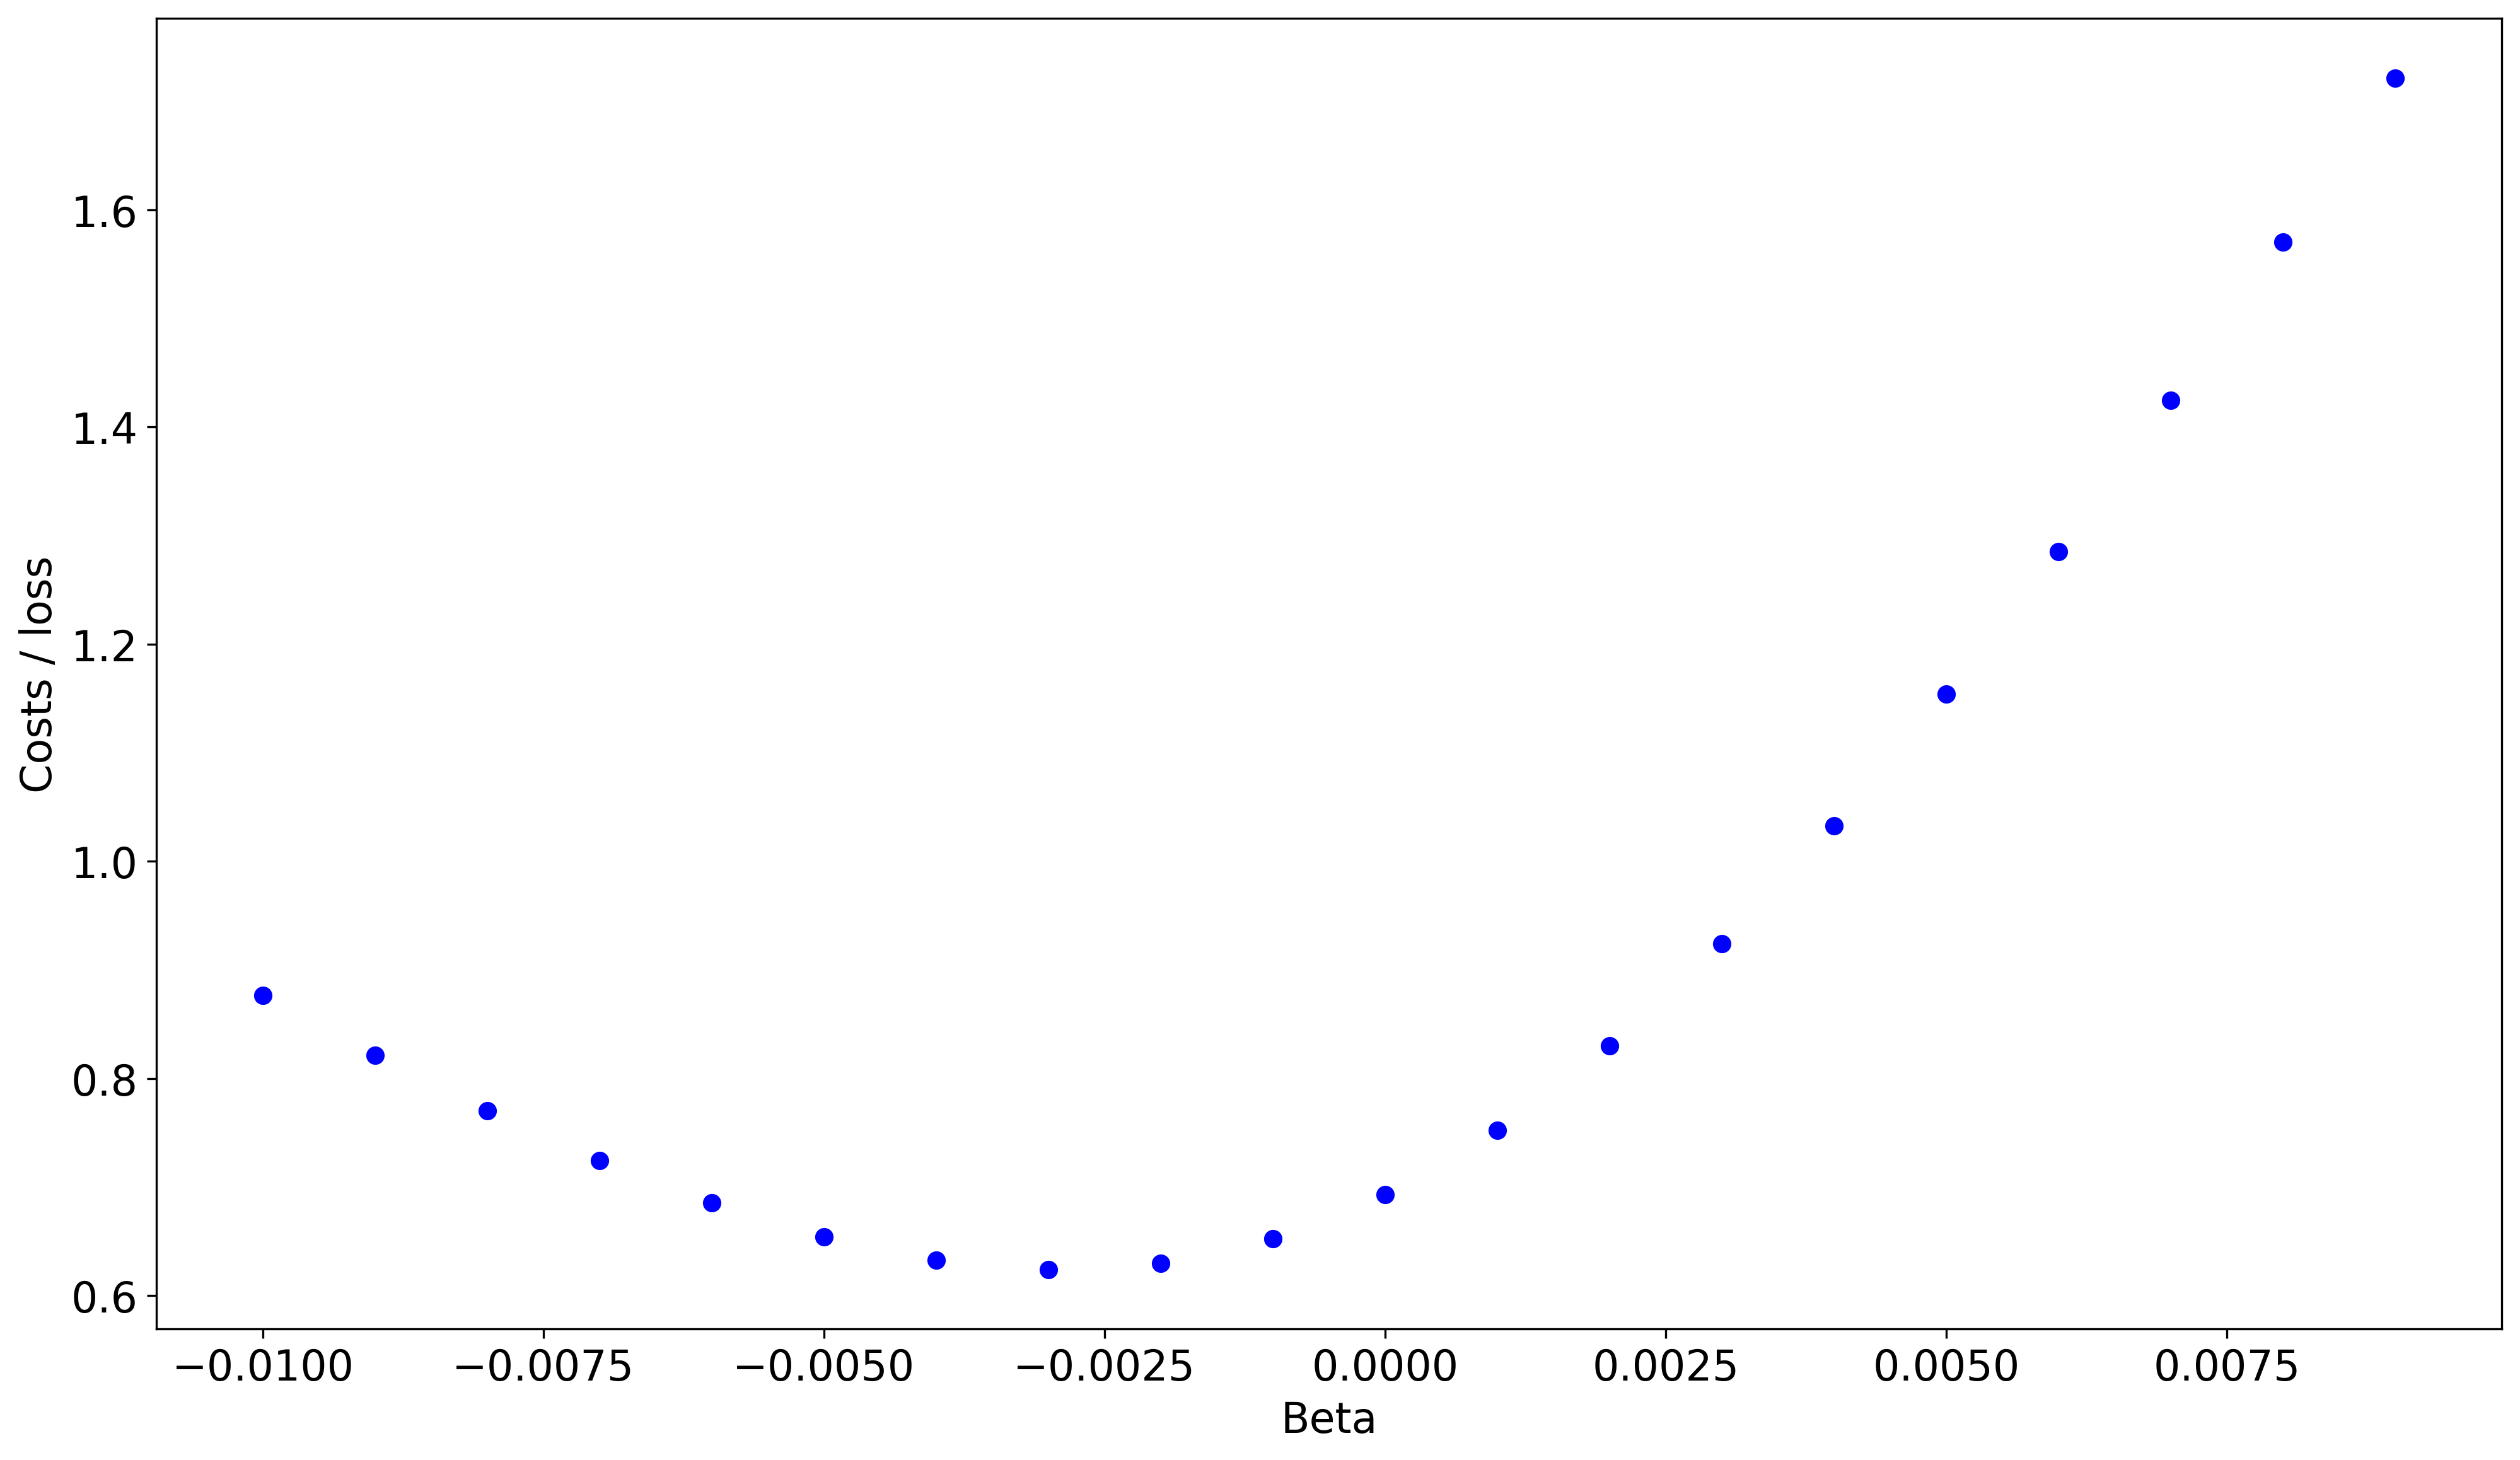

In [ ]:
for beta_s in range(-10, 10, 1):
    cost_beta = J_cost_fun_bin(beta_s/1000)
    plt.xlabel('Beta')
    plt.ylabel('Costs / Loss')
    plt.plot(beta_s/1000, cost_beta, color='blue', marker='o')

In [6]:
def J_deriv_bin(beta):
    pd_pred = np.exp(beta * x) / (1 + np.exp(beta * x))
    tmp = np.mean(x * (pd_pred -d))
    return tmp 

Solution for beta: -0.0029


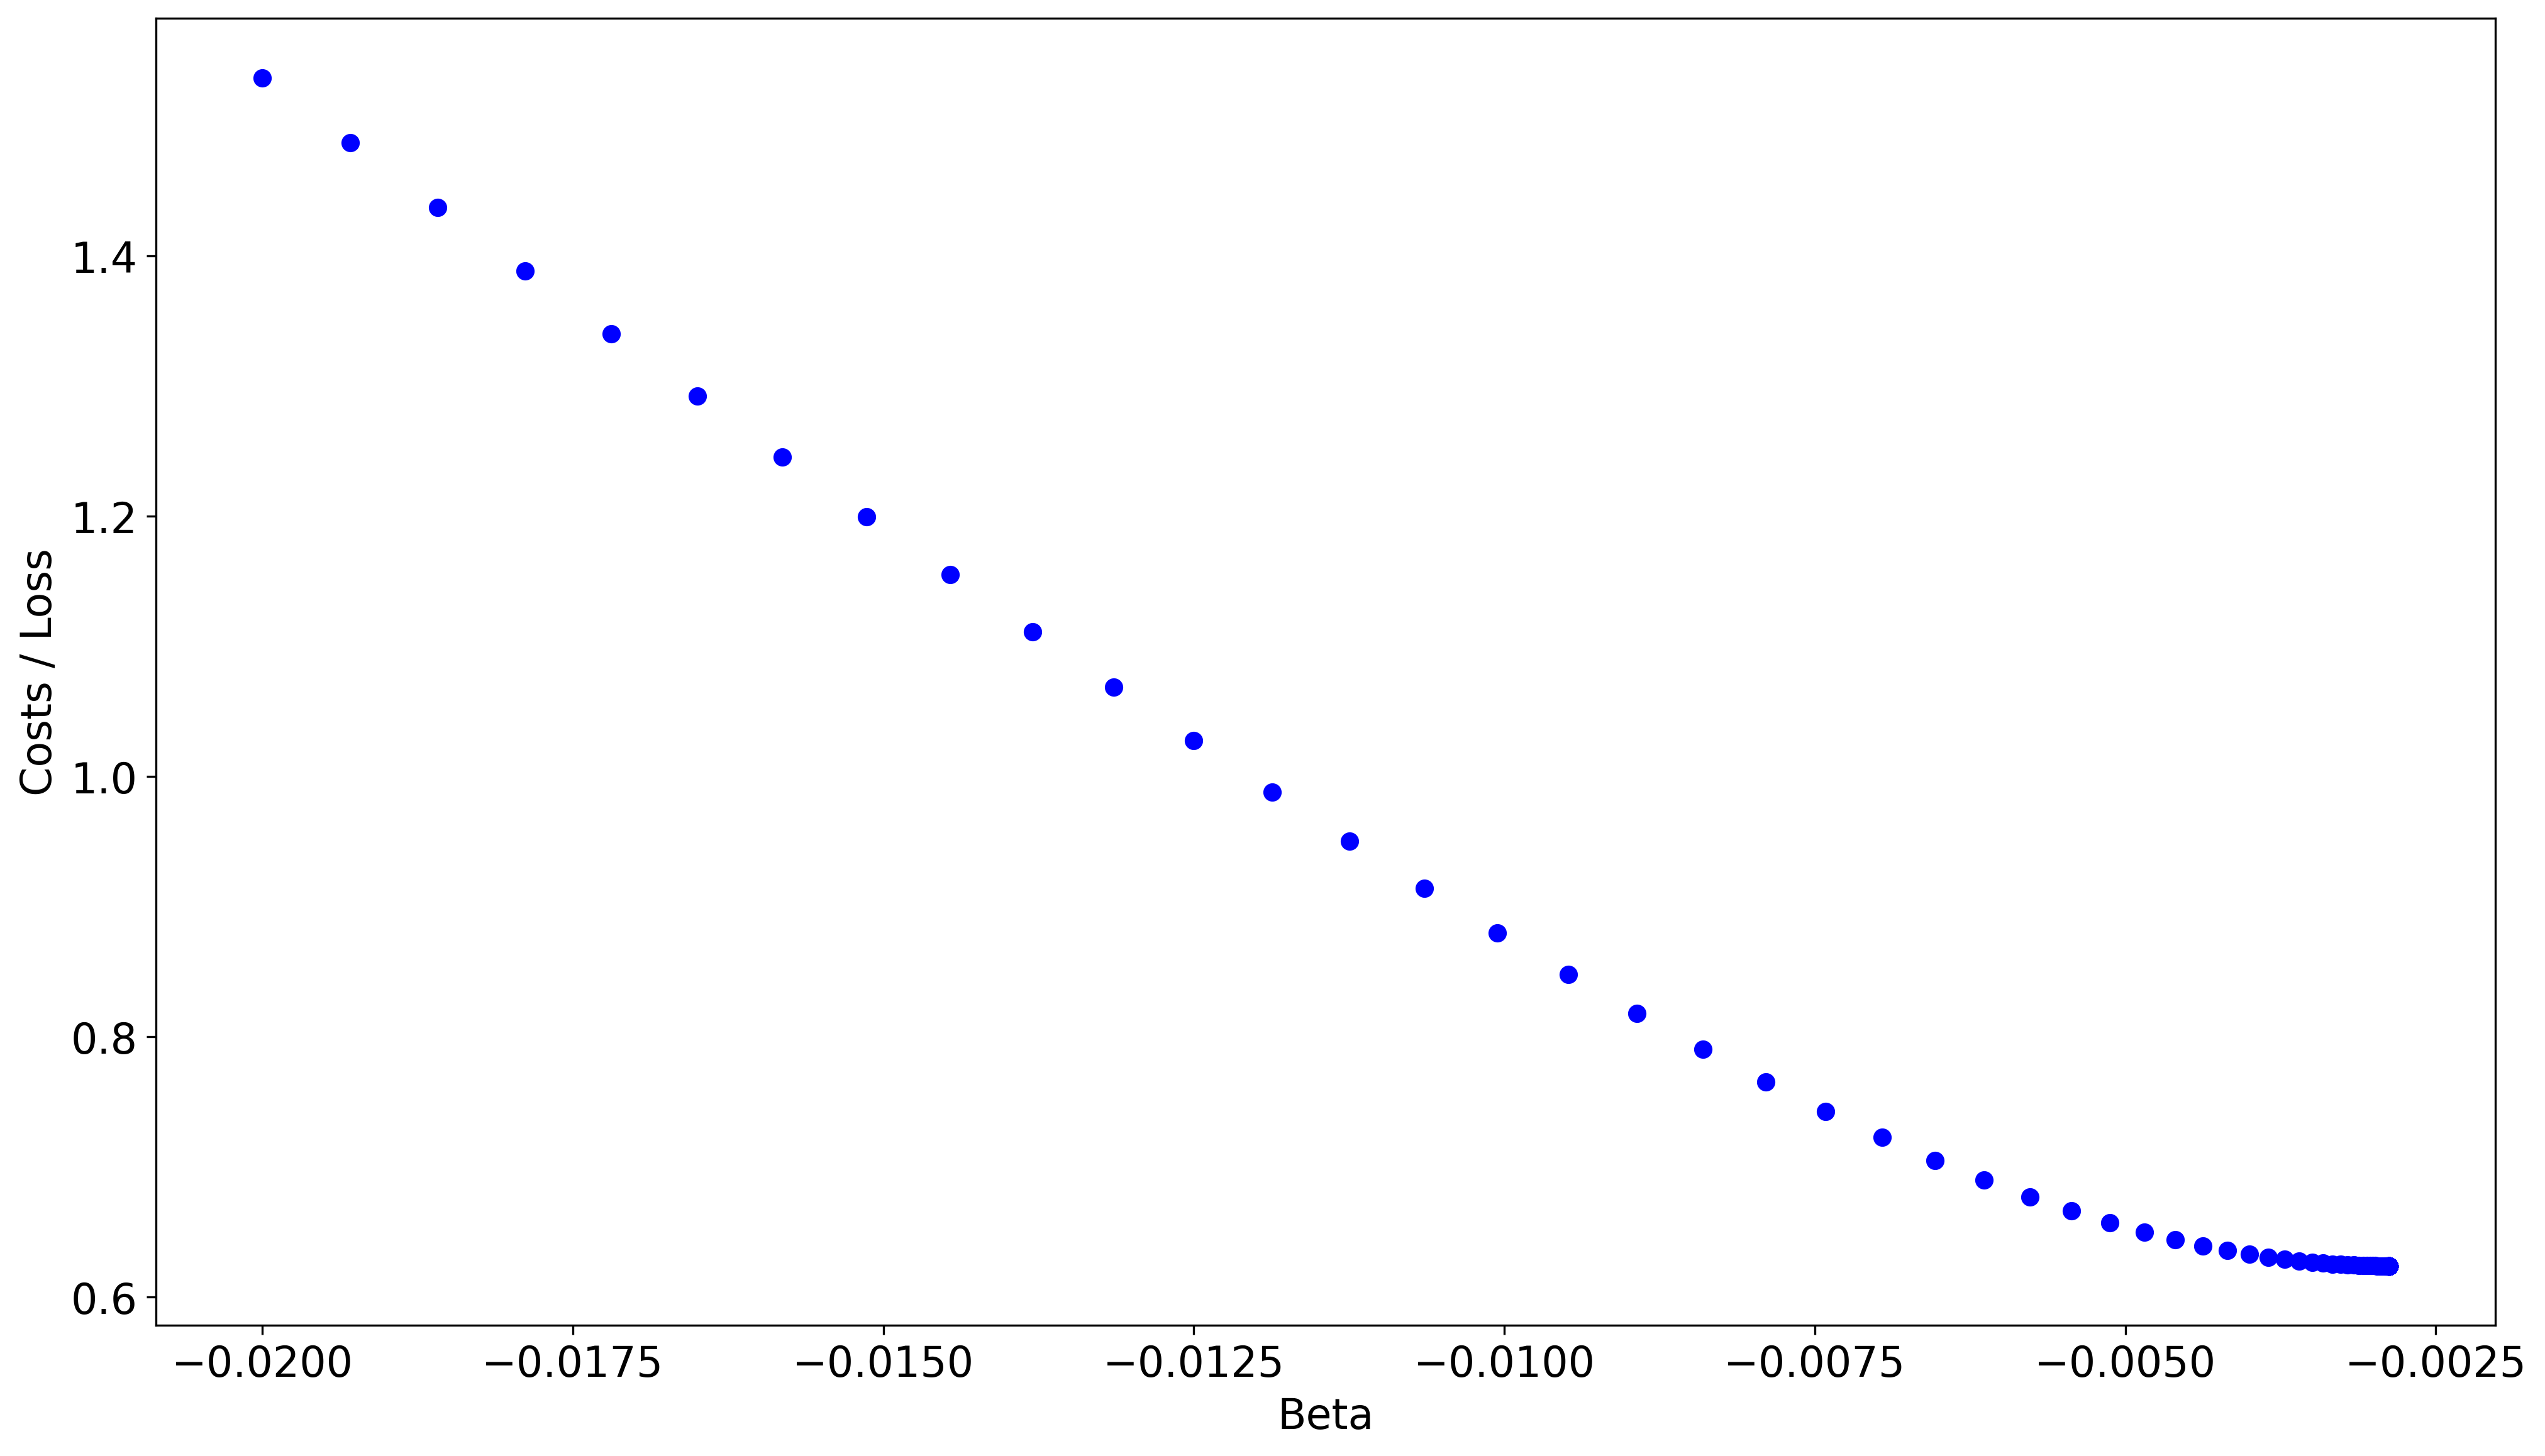

In [7]:
lr = 0.00001
beta_s = -0.02

for i in range(0, 1000):
    d_beta = J_deriv_bin(beta_s)
    cost = J_cost_fun_bin(beta_s)
    plt.xlabel('Beta')
    plt.ylabel('Costs / Loss')
    plt.plot(beta_s, cost, color='blue', marker='o')
    beta_s = beta_s - lr * d_beta

print('Solution for beta:', np.round(beta_s, 4))

In [8]:
model_logit = sm.Logit(d, x)
results_logit = model_logit.fit()

print('Solution for beta:', np.round(results_logit.params, 4))

Optimization terminated successfully.
         Current function value: 0.623958
         Iterations 4
Solution for beta: [-0.0029]


In [9]:
x = x.reshape(-1, 1)
model_lr = LogisticRegression(penalty='none', fit_intercept=False, solver='lbfgs', tol=1e-15, max_iter=1000)
model_lr.fit(x, d)

print('Solution for beta:', np.round(model_lr.coef_, 4))

Solution for beta: [[-0.0029]]


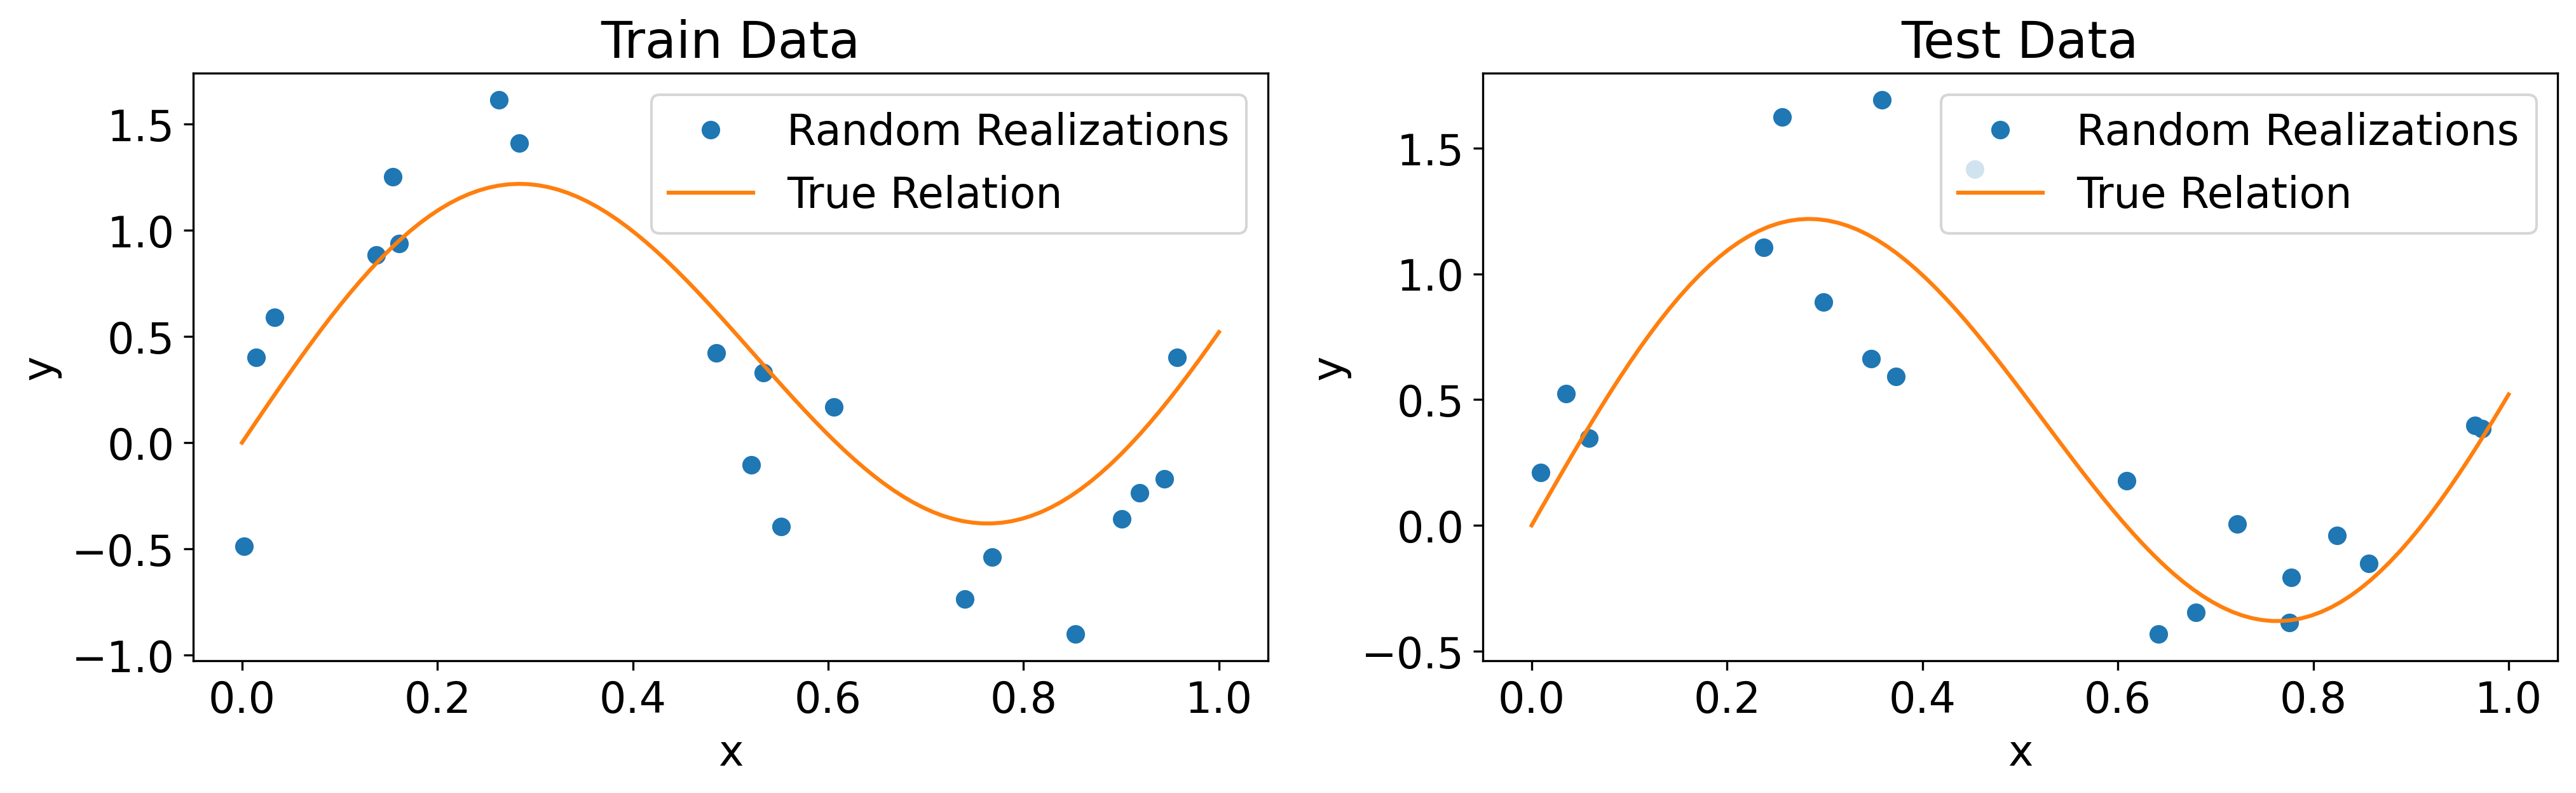

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

np.random.seed(seed=12)  
N_sim = 20  
mu, sigma = 0, 0.3  
x_train = np.random.uniform(low=0.0, high=1.0, size=N_sim)  
eps_train = np.random.normal(mu, sigma, N_sim)  
y_train = 0.8 * x_train + np.sin(6 * x_train) + eps_train  

np.random.seed(seed=13)  
x_test = np.random.uniform(low=0.0, high=1.0, size=N_sim)  
eps_test = np.random.normal(mu, sigma, N_sim)  
y_test = 0.8 * x_test + np.sin(6 * x_test) + eps_test

plt.rcParams['figure.figsize'] = (16, 4)  
plt.rcParams.update({'font.size': 16})  
plt.subplot(1,2,1)  
x_axis = np.linspace(0, 1, 100)  
y_true = 0.8 * x_axis + np.sin(6 * x_axis)  
plt.plot(x_train, y_train, linestyle='none', marker='o', label='Random Realizations')  
plt.plot(x_axis, y_true, label="True Relation")  
plt.xlabel('x')  
plt.ylabel('y')  
plt.title('Train Data') 
plt.legend()  
plt.subplot(1,2,2)  
plt.plot(x_test, y_test, linestyle='none', marker='o', label='Random Realizations')  
plt.plot(x_axis, y_true, label="True Relation")  
plt.xlabel('x')  
plt.ylabel('y')  
plt.legend()  
plt.title('Test Data')  
plt.show() 


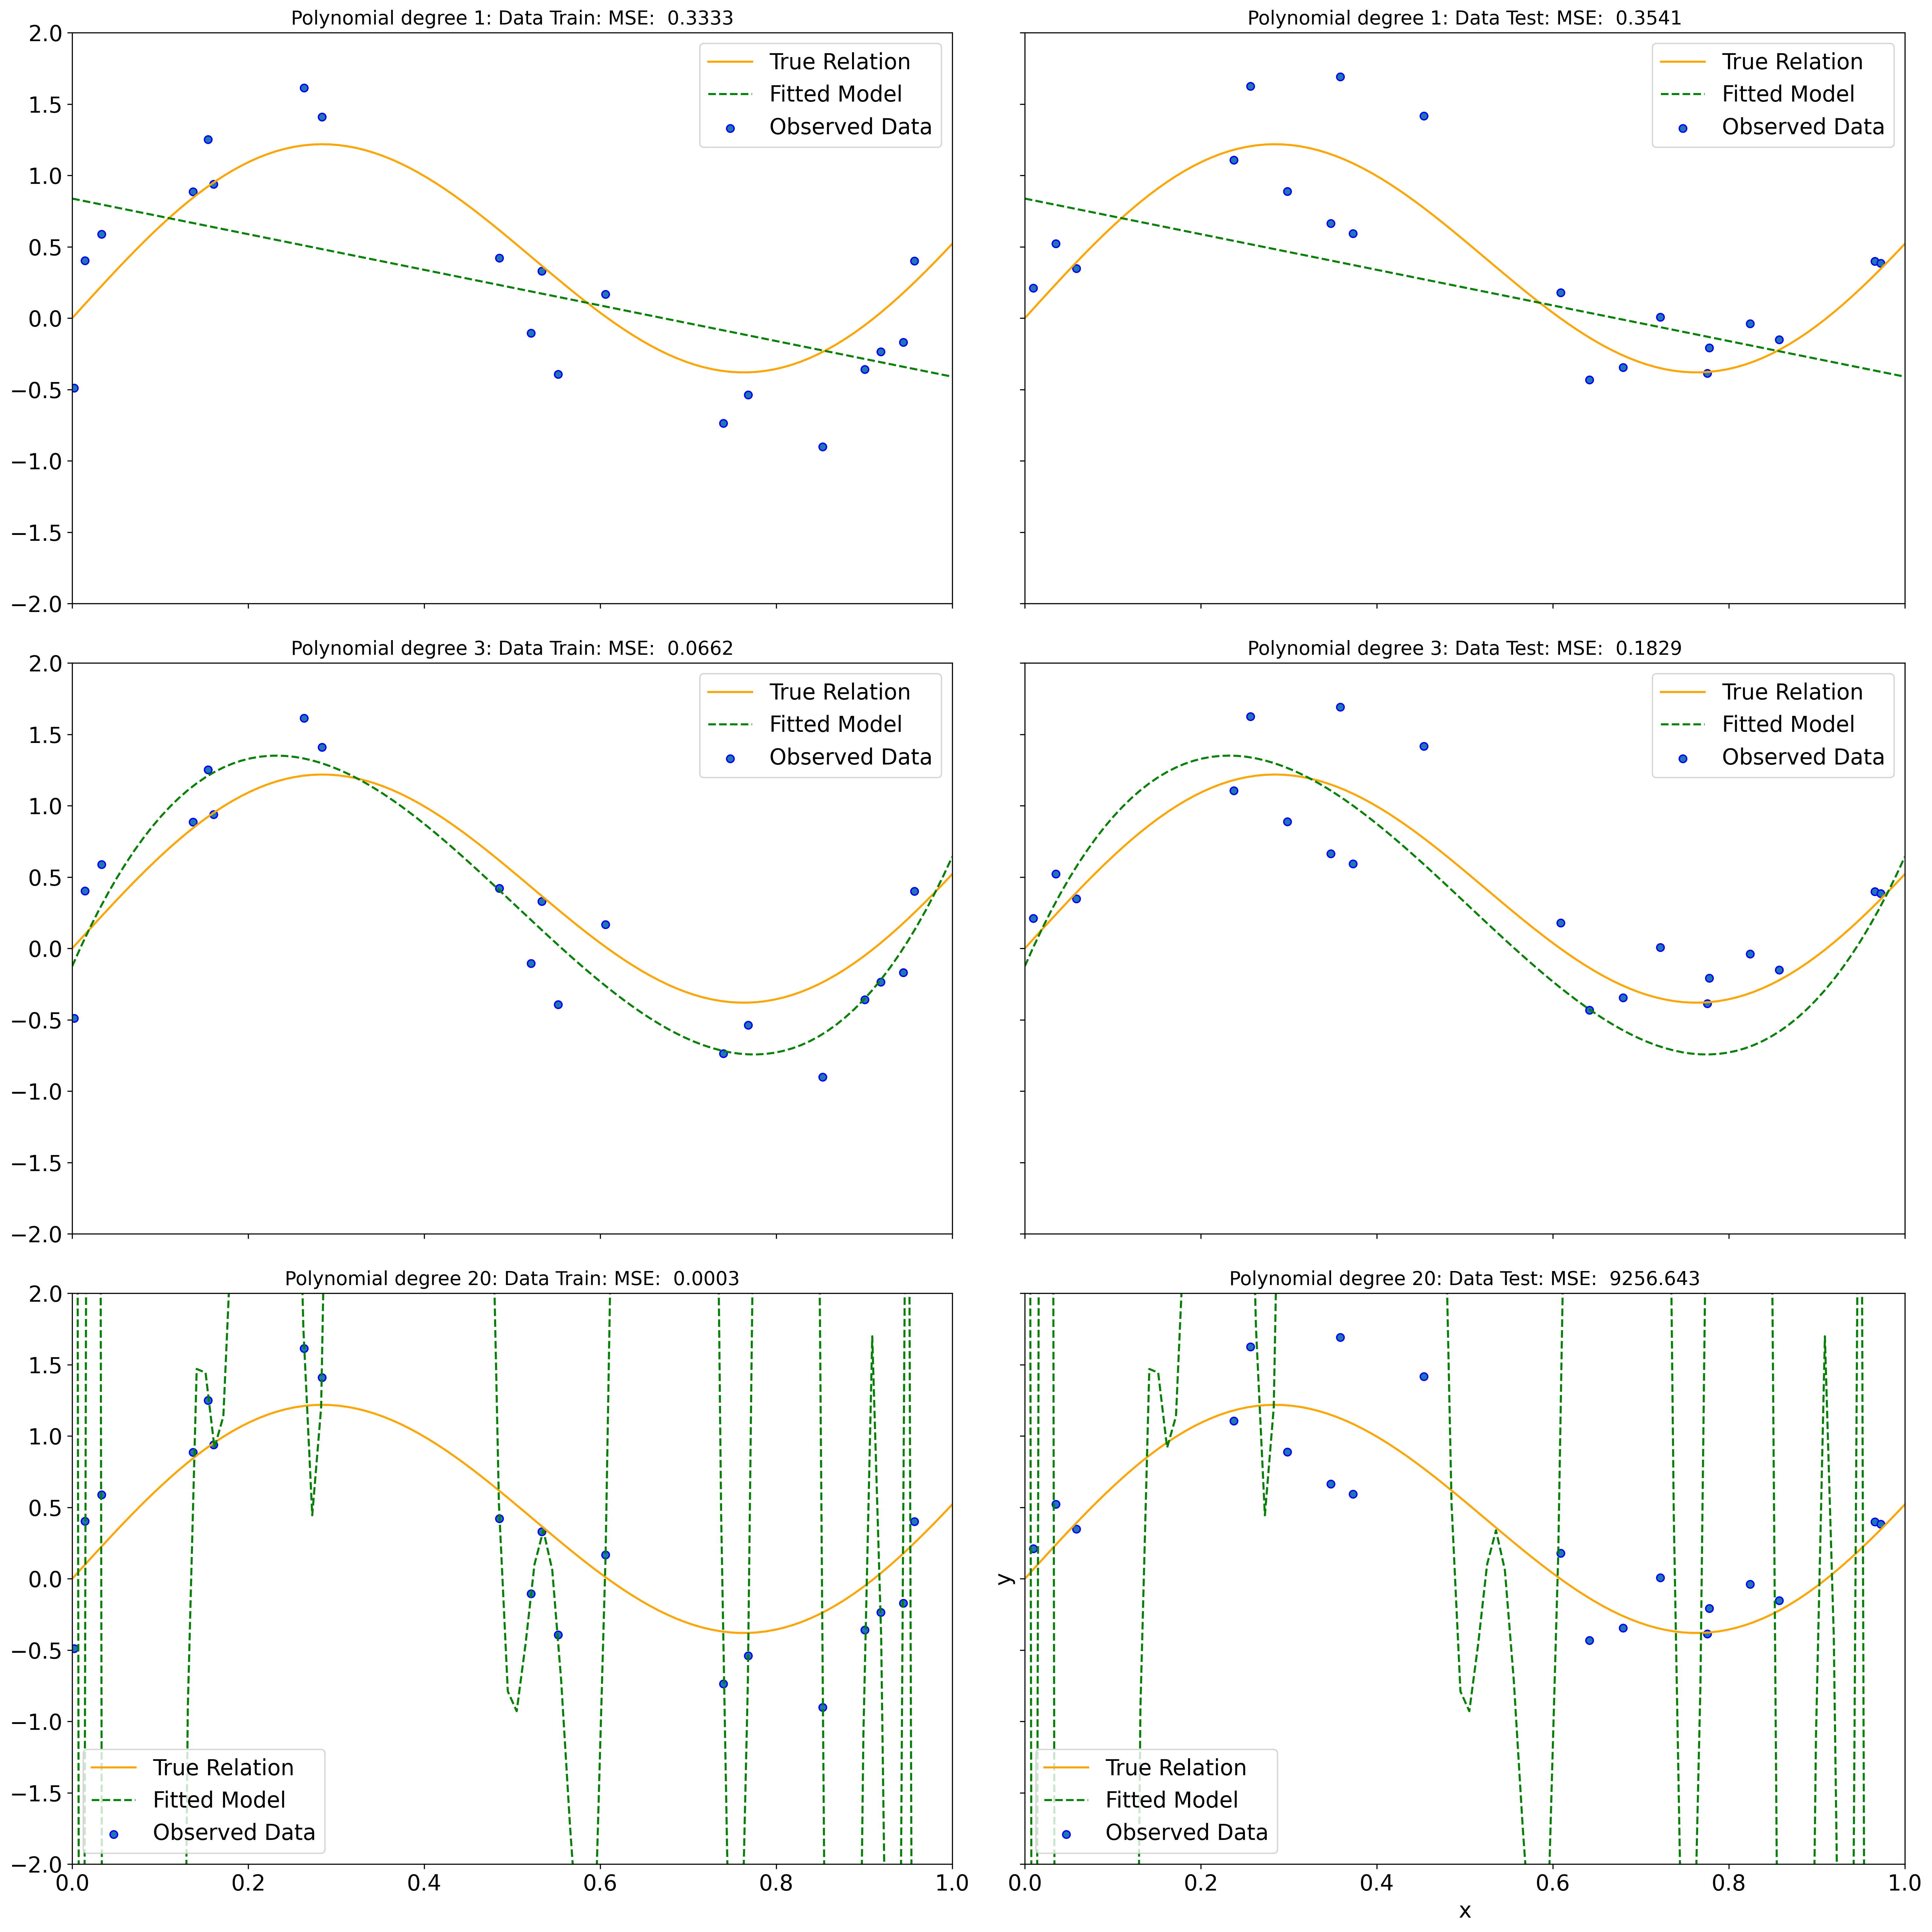

In [21]:
fig, axes = plt.subplots(3,2, sharex=True, sharey=True, figsize=(20,20))  
degree =[1,1,3,3,20,20]  

def plot(x,y,mse,degree,data):  
    ax.plot(x_axis, y_true, label="True Relation", color='orange')  
    ax.plot(x_axis, pipeline.predict(x_axis[:, np.newaxis]),label="Fitted Model", ls ='--'  , color='g')  
    ax.scatter(x.reshape(-1, 1), y, edgecolor='b', s=30, label="Observed Data")  
    plt.xlabel('x')  
    plt.ylabel('y')  
    plt.xlim((0, 1))  
    plt.ylim((-2, 2))  
    ax.set_title('Polynomial degree {}:'.format(degree)+' Data {}:'.format(data) +' MSE:  {}'.format(mse), fontsize=14)  
    ax.legend(loc="best")  
    
for i,ax in enumerate(axes.flatten()):
    polynomial_features = PolynomialFeatures(degree=degree[i], include_bias=False)  
    linear_regression = LinearRegression()  
    pipeline = Pipeline([('polynomial_features', polynomial_features), ('linear_regression'  , linear_regression)])  
    pipeline.fit(x_train.reshape(-1, 1), y_train)  
    x_axis = np.linspace(0, 1, 100)  
    y_true = 0.8 * x_axis + np.sin(6 * x_axis)  
      
    #Compute MSE  
    if i in [0,2,4]:  
        x=x_train  
        y=y_train  
        data='Train'  
        y_pred = pipeline.predict(x.reshape(-1, 1))  
        mse = mean_squared_error(y_train, y_pred).round(4)  
    if i in [1,3,5]:  
        x=x_test  
        y=y_test  
        data='Test'  
        y_pred = pipeline.predict(x.reshape(-1, 1))  
        mse = mean_squared_error(y_test, y_pred).round(4)  
    plot(x,y,mse,degree[i],data)  

plt.tight_layout()
plt.show() 


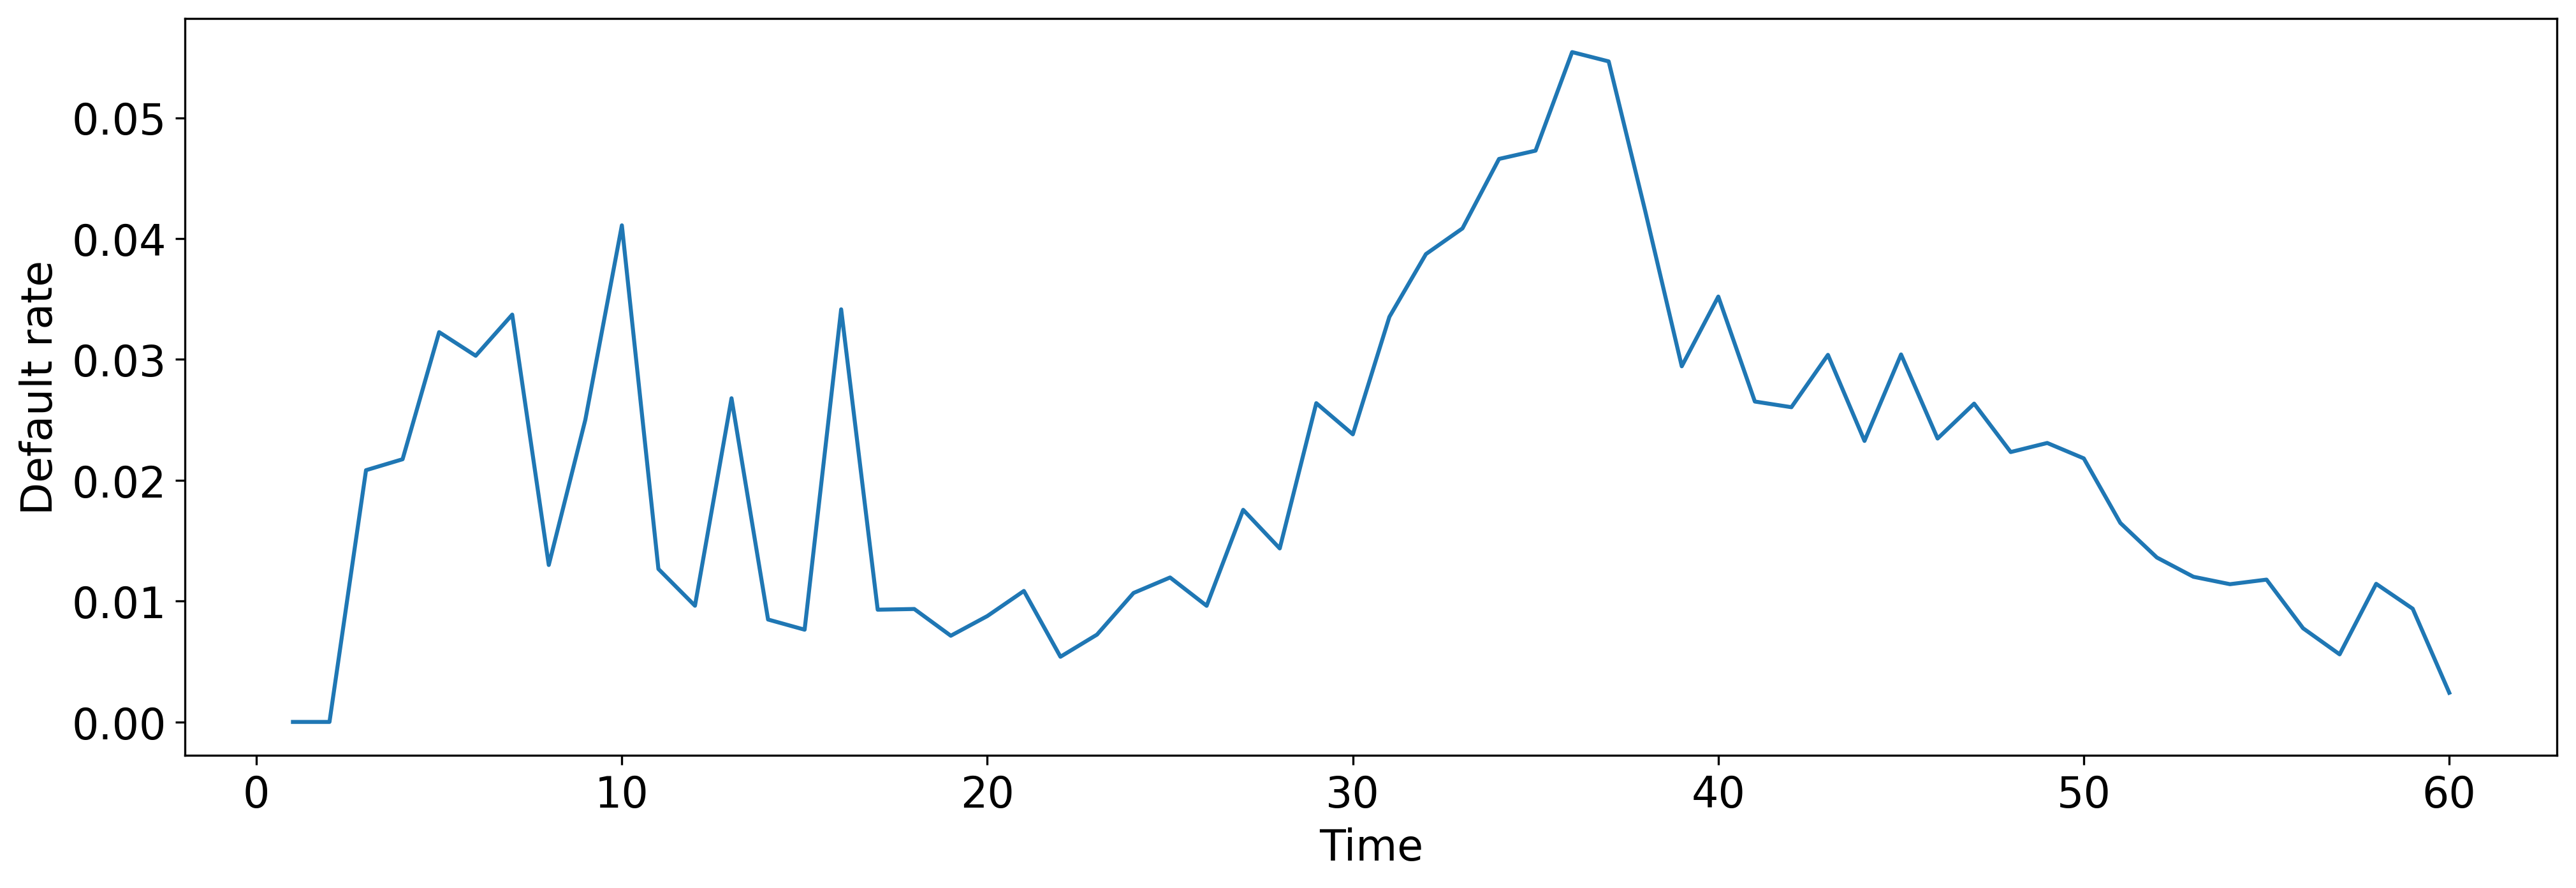

In [25]:
default_rate = data.groupby('time')['default_time'].mean().reset_index(drop=False)  
plt.rcParams['figure.figsize'] = (16, 5)  
plt.rcParams.update({'font.size': 16})  
plt.plot('time', 'default_time', data=default_rate)  
plt.xlabel('Time')  
plt.ylabel('Default rate')  
plt.show() 

In [26]:
data_train = data[data['time'] < 27]  
data_test = data[data['time'] > 26]  
data_test = data_test[data_test['time'] <= 40]  

In [27]:
X_train = data_train['FICO_orig_time'].values.reshape(-1,1)  
y_train = data_train['default_time'].values.reshape(-1)  
X_test = data_test['FICO_orig_time'].values.reshape(-1,1)  
y_test = data_test['default_time'].values.reshape(-1)  
print('Default rate in training sample:', np.mean(y_train).round(3))  
print('Default rate in test sample:', np.mean(y_test).round(3))

Default rate in training sample: 0.011
Default rate in test sample: 0.035


In [28]:
model_lr = LogisticRegression(penalty='none', fit_intercept=True, solver='newton-cg', tol=1e-15, max_iter=10000)  
model_lr.fit(X_train, y_train)  
print('Coefficient:' ,np.round(model_lr.coef_,4))  
print('Intercept:', np.round(model_lr.intercept_,4)) 

Coefficient: [[-0.0119]]
Intercept: [2.9807]


In [29]:
x = sm.add_constant(X_train, prepend=True)  
model_logit = sm.Logit(y_train, x).fit()  
print(model_logit.summary()) 

Optimization terminated successfully.
         Current function value: 0.055091
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                13275
Model:                          Logit   Df Residuals:                    13273
Method:                           MLE   Df Model:                            1
Date:                Mon, 28 Jul 2025   Pseudo R-squ.:                 0.06909
Time:                        17:11:03   Log-Likelihood:                -731.33
converged:                       True   LL-Null:                       -785.61
Covariance Type:            nonrobust   LLR p-value:                 2.026e-25
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9807      0.723      4.125      0.000       1.564       4.397
x1            -0.0119      0.

In [30]:
predictions = model_lr.predict_proba(X_train)[:,1].T  
print(np.mean(predictions).round(3)) 

predictions = model_lr.predict_proba(X_test)[:,1].T  
print(np.mean(predictions).round(3)) 

0.011
0.009


In [31]:
neg_log_loss = cross_val_score(model_lr, X_train, y_train, cv=5, scoring='neg_log_loss')  
print(np.round(neg_log_loss,3))

[-0.06  -0.051 -0.054 -0.058 -0.055]
